# Fourier Analysis of Molecular Hamiltonian Expectation Values

Using VQE, we want to compute 

\begin{equation}
E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle
\tag{1}
\end{equation}

where $H$ is a molecular hamiltonian. After this, we want to find the optimal angle $\theta^* = \arg\min_\theta E(\theta)$. To gain insight into the structure of $E(\theta)$, we can perform a Fourier analysis. This will allow us to extract the Fourier coefficients and understand how they vary with the H-H distance.


## Molecular Hamiltonians

### $H_2$

The standard VQE Hamiltonian construction for $H_2$ follows the steps:

1. Obtain the eletronic Hamiltonian in termos of fermion operators ($a_p$ and $a_p^{\dagger}$): `build_electronic_hamiltonian()`
2. Map the eletronic Hamiltonian to the qubit one in terms of Pauli strings: `build_qubit_hamiltonian()`

In the final step, we extract the Pauli strings using `pauli_terms_from_qubit_hamiltonian()`.

In [1]:
from src.vqe.hamiltonian import (
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

ferm_op, constant_energy = build_electronic_hamiltonian(
    atom_string="H 0 0 0; H 0 0 0.74",
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op = build_qubit_hamiltonian(ferm_op, mapper="jw")
terms = pauli_terms_from_qubit_hamiltonian(qubit_op)

print("constant_energy:", constant_energy)
for pauli, coeff in terms:
    print(coeff, pauli)

constant_energy: 0.7151043390810812
-0.8121706072487132 IIII
0.17141282644776906 IIIZ
-0.2234315369081336 IIZI
0.12062523483390414 IIZZ
0.17141282644776912 IZII
0.16868898170361202 IZIZ
-0.2234315369081336 ZIII
0.16592785033770333 ZIIZ
0.04530261550379917 YYYY
0.04530261550379917 XXYY
0.04530261550379917 YYXX
0.04530261550379917 XXXX
0.16592785033770333 IZZI
0.1744128761226153 ZIZI
0.12062523483390414 ZZII


It is possible to reduce the number of qubits/Pauli terms if we use parity symmetry:

In [5]:
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom = "H 0 0 0; H 0 0 0.74"

problem = build_electronic_problem(
    atom_string=atom,
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

ferm_op, const = build_electronic_hamiltonian(
    atom_string=atom,
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op_2q = build_qubit_hamiltonian(
    ferm_op,
    mapper="parity",
    z2symmetry_reduction=False,   # mantém em 2 qubits
    problem=problem,
    num_particles=problem.num_particles,
)

print("num_qubits:", qubit_op_2q.num_qubits)
print(pauli_terms_from_qubit_hamiltonian(qubit_op_2q)[:10])

num_qubits: 2
[('II', -1.053421076916521), ('IZ', 0.39484436335590256), ('ZI', -0.3948443633559026), ('ZZ', -0.011246157150820668), ('XX', 0.1812104620151967)]


This result almost matches Kandala et al (2017), up to relative signs: 

``` (ZZ 0.011280 ZI 0.397936 IZ 0.397936  XX 0.180931). ```

We can also use a Z2 symmetry reduction to reduce even further the hamiltonian to 1 qubit. Let us test which Hamiltonian gives the best match to the exact FCI result: 

In [6]:
import numpy as np
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import build_qubit_hamiltonian

# Build three H2 Hamiltonians from the same electronic problem
qubit_ops = {
    "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
    "2q_parity": build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=False,
        problem=problem,
        num_particles=problem.num_particles,
    ),
    "1q_parity_z2": build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=True,
        problem=problem,
        num_particles=problem.num_particles,
    ),
}

rows = []
for label, qop in qubit_ops.items():
    ansatz = build_ansatz(
        name="real_amplitudes",
        num_qubits=qop.num_qubits,
        reps=2,
    )
    optimizer = get_optimizer("cobyla", max_iter=200)

    vqe_res = run_vqe(
        qubit_op=qop,
        ansatz=ansatz,
        optimizer=optimizer,
        constant_energy=float(const),
        seed=137,
    )

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
    exact_total = float(np.real(exact.eigenvalue) + float(const))

    rows.append({
        "hamiltonian": label,
        "num_qubits": qop.num_qubits,
        "vqe_total_energy": float(vqe_res["energy"]),
        "exact_total_energy": exact_total,
        "abs_error": abs(float(vqe_res["energy"]) - exact_total),
        "eval_count": int(vqe_res["eval_count"]),
    })

rows = sorted(rows, key=lambda x: x["num_qubits"], reverse=True)
for row in rows:
    print(row)

{'hamiltonian': '4q_jw', 'num_qubits': 4, 'vqe_total_energy': -1.1167590753609047, 'exact_total_energy': -1.1372838344885006, 'abs_error': 0.020524759127595882, 'eval_count': 200}
{'hamiltonian': '2q_parity', 'num_qubits': 2, 'vqe_total_energy': -1.1372838335556938, 'exact_total_energy': -1.1372838344885001, 'abs_error': 9.328062766655876e-10, 'eval_count': 76}
{'hamiltonian': '1q_parity_z2', 'num_qubits': 1, 'vqe_total_energy': -1.137283834480362, 'exact_total_energy': -1.1372838344885003, 'abs_error': 8.138378859712248e-12, 'eval_count': 36}


### LiH (not working with FCI)

First we obtain the simplest Hamiltonian with an active space (2,2).

In [5]:
import importlib
import numpy as np

if not hasattr(np, "in1d"):
    np.in1d = np.isin

import src.vqe.hamiltonian as hamiltonian_mod
importlib.reload(hamiltonian_mod)

build_electronic_problem = hamiltonian_mod.build_electronic_problem
build_electronic_hamiltonian = hamiltonian_mod.build_electronic_hamiltonian
build_qubit_hamiltonian = hamiltonian_mod.build_qubit_hamiltonian
pauli_terms_from_qubit_hamiltonian = hamiltonian_mod.pauli_terms_from_qubit_hamiltonian

# LiH at a representative bond length (Angstrom)
atom_lih = "Li 0 0 0; H 0 0 1.545"

# Kandala-like approximation for LiH in STO-3G:
# - freeze Li 1s core
# - keep 3 spatial orbitals (=> 6 spin-orbitals)
# - with 2 active electrons => CAS(2,3)
# The explicit active_orbitals selection lets us exclude two orbitals consistently.
active_space_kandala = (2, 3)
active_orbitals_kandala = [0, 1, 2]

ferm_op_lih, constant_energy_lih = build_electronic_hamiltonian(
    atom_string=atom_lih,
    basis="sto-3g",
    active_space=active_space_kandala,
    active_orbitals=active_orbitals_kandala,
    freeze_core=True,
)

problem_ref = build_electronic_problem(
    atom_string=atom_lih,
    basis="sto-3g",
    active_space=active_space_kandala,
    active_orbitals=active_orbitals_kandala,
    freeze_core=True,
)

qubit_op_lih = build_qubit_hamiltonian(
    ferm_op_lih,
    mapper="bk",
    z2symmetry_reduction=True,
    problem=problem_ref,
)
terms_lih = pauli_terms_from_qubit_hamiltonian(qubit_op_lih)

print("atom:", atom_lih)
print("active_space:", active_space_kandala)
print("active_orbitals:", active_orbitals_kandala)
print("constant_energy:", constant_energy_lih)
print("num_qubits:", qubit_op_lih.num_qubits)
print("num_pauli_terms:", len(terms_lih))
for pauli, coeff in terms_lih:
    print(coeff, pauli)

atom: Li 0 0 0; H 0 0 1.545
active_space: (2, 3)
active_orbitals: [0, 1, 2]
constant_energy: -6.792223915021593
num_qubits: 3
num_pauli_terms: 34
-0.3931381946187643 III
-0.10300198309489338 IIZ
0.2757166284318585 ZZZ
-0.4271332638578527 ZZI
0.10300198309489349 ZII
-0.2073911576914914 ZIZ
-0.01360522854452937 YYI
-0.013605224753044659 YYZ
0.01360522854452937 XXI
0.013605224753044659 XXZ
-0.2757166284318586 IZI
0.11261387963466069 IZZ
0.013605228544529373 ZZX
0.013605228544529373 IIX
-0.013605224753044659 IZX
-0.013605224753044659 ZIX
0.0062679403102556975 XXX
-0.0062679403102556975 YYX
-0.005932312376703485 XIX
-0.005932312376703485 XZX
-0.005932312376703485 YZY
-0.005932312376703485 YIY
0.004808814870608493 ZXX
-0.004808814870608493 IXX
0.004808814870608493 IYY
-0.004808814870608493 ZYY
-0.004808814870608493 XIZ
-0.004808814870608493 XZZ
-0.004808814870608493 XII
-0.004808814870608493 XZI
0.01032333803518957 ZXZ
-0.01032333803518957 IXZ
0.01032333803518957 ZXI
-0.01032333803518957 IXI

### CASCI, FCI and VQE Comparisons for all molecules

Using configured distance grid (cache distance grid disabled for this system).
Active setup:
{'system_toggle': 'LiH', 'molecule': 'LiH', 'active_reference': 'CASCI', 'basis': 'sto-3g', 'active_space': (2, 3), 'active_orbitals': [0, 1, 2], 'freeze_core': True, 'mapper': 'parity', 'z2': True, 'ansatz_name': 'real_amplitudes', 'ansatz_reps': 3, 'optimizer': 'cobyla', 'optimizer_max_iter': 450, 'prefer_cache_distance_grid': False, 'force_distance_points': None, 'num_distances': 14, 'distance_min': 0.5, 'distance_max': 2.5, 'run_full_fci': True}
Full FCI points: 14 out of 14
Reference geometry diagnostics:
{'distance_ref': 1.576923076923077, 'num_qubits_ref': 3, 'num_terms_ref': 34, 'constant_energy_ref': -6.799164172420261}
Computing 14 missing points...


,distance,atom,molecule,basis,active_space,active_orbitals,freeze_core,mapper,z2,use_num_particles,...,exact_vs_full_fci_abs_error,vqe_vs_full_fci_abs_error,active_vs_full_fci_abs_error,eval_count,ansatz_name,ansatz_reps,optimizer,optimizer_max_iter,seed,status
0,0.500000,Li 0 0 0; H 0 0 0.5,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.016429,0.016429,0.016429,450,real_amplitudes,3,cobyla,450,137,ok
1,0.653846,Li 0 0 0; H 0 0 0.6538461538461539,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.017102,0.017370,0.017102,450,real_amplitudes,3,cobyla,450,137,ok
2,0.807692,Li 0 0 0; H 0 0 0.8076923076923077,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.016758,0.016759,0.016758,450,real_amplitudes,3,cobyla,450,137,ok
3,0.961538,Li 0 0 0; H 0 0 0.9615384615384616,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.015989,0.015994,0.015989,450,real_amplitudes,3,cobyla,450,137,ok
4,1.115385,Li 0 0 0; H 0 0 1.1153846153846154,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.015608,0.016303,0.015608,450,real_amplitudes,3,cobyla,450,137,ok
5,1.269231,Li 0 0 0; H 0 0 1.2692307692307692,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.015941,0.015942,0.015941,450,real_amplitudes,3,cobyla,450,137,ok
6,1.423077,Li 0 0 0; H 0 0 1.4230769230769231,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.017079,0.017080,0.017079,450,real_amplitudes,3,cobyla,450,137,ok
7,1.576923,Li 0 0 0; H 0 0 1.576923076923077,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.019039,0.019039,0.019039,414,real_amplitudes,3,cobyla,450,137,ok
8,1.730769,Li 0 0 0; H 0 0 1.7307692307692308,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.021839,0.021839,0.021839,450,real_amplitudes,3,cobyla,450,137,ok
9,1.884615,Li 0 0 0; H 0 0 1.8846153846153846,LiH,sto-3g,"(2, 3)","[0, 1, 2]",True,parity,True,True,...,0.025511,0.026272,0.025511,450,real_amplitudes,3,cobyla,450,137,ok


,system,active_reference,points_used,num_qubits_mode,num_terms_mode,min_exact_total_energy,min_vqe_total_energy,min_ref_energy,mean_exact_vs_ref_abs_error,mean_vqe_vs_exact_abs_error,mean_vqe_vs_ref_abs_error,mean_eval_count,mean_exact_vs_full_fci_abs_error,mean_vqe_vs_full_fci_abs_error,mean_active_vs_full_fci_abs_error
0,LiH,CASCI,14,3,34,-7.863582,-7.863582,-7.863582,4.377451e-15,0.000135,0.000135,437.0,0.024196,0.02433,0.024196


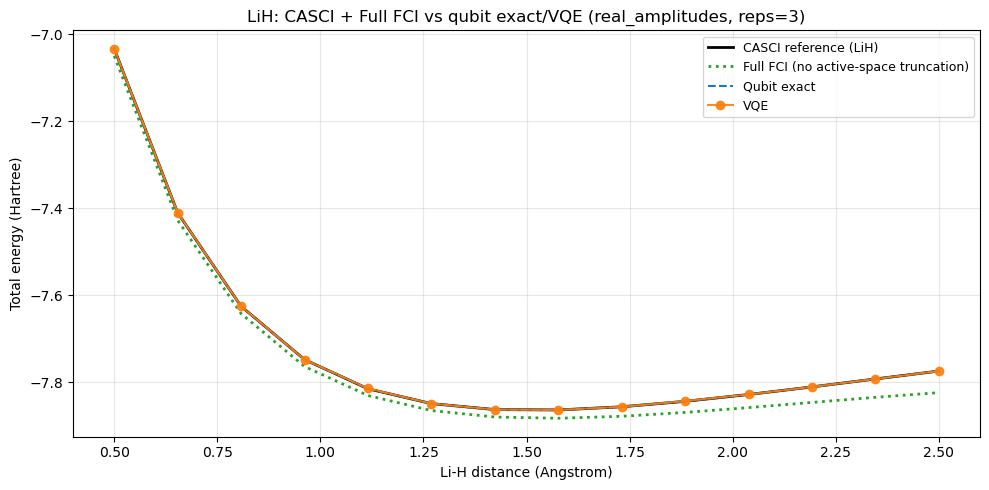

In [38]:
import importlib
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
import src.vqe.hamiltonian as hamiltonian_mod
import src.solvers.fci as fci_mod
import src.data.cache as cache_mod

importlib.reload(hamiltonian_mod)
importlib.reload(fci_mod)
importlib.reload(cache_mod)
build_electronic_problem = hamiltonian_mod.build_electronic_problem
build_electronic_hamiltonian = hamiltonian_mod.build_electronic_hamiltonian
build_qubit_hamiltonian = hamiltonian_mod.build_qubit_hamiltonian
cache_fci = cache_mod.cache_fci


def _slug(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "-", str(value)).strip("-").lower()


def _dkey(value: float) -> str:
    return f"{float(value):.8f}"


def _system_cfg(system_name: str) -> dict:
    s = system_name.strip().lower()

    if s == "lih":
        return {
            "molecule": "LiH",
            "bond_label": "Li-H",
            "basis": "sto-3g",
            "active_space": (2, 3),
            "active_orbitals": [0, 1, 2],
            "freeze_core": True,
            "mapper": "parity",
            "z2": True,
            "use_num_particles": True,
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 3,
            "optimizer_max_iter": 450,
            "default_distances": np.linspace(0.5, 2.5, 14),
            "run_full_fci_default": True,
            "max_points_default": 24,
            "prefer_cache_distance_grid": False,
            "geometry_fn": lambda d: f"Li 0 0 0; H 0 0 {float(d)}",
        }

    if s == "h2":
        return {
            "molecule": "H2",
            "bond_label": "H-H",
            "basis": "sto-3g",
            "active_space": (2, 2),
            "active_orbitals": None,
            "freeze_core": False,
            "mapper": "parity",
            "z2": True,
            "use_num_particles": True,
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 2,
            "optimizer_max_iter": 220,
            "default_distances": np.linspace(0.5, 2.5, 12),
            "run_full_fci_default": False,
            "max_points_default": None,
            "prefer_cache_distance_grid": True,
            "geometry_fn": lambda d: f"H 0 0 0; H 0 0 {float(d)}",
        }

    if s == "beh2":
        return {
            "molecule": "BeH2",
            "bond_label": "Be-H",
            "basis": "sto-3g",
            "active_space": (4, 4),
            "active_orbitals": [0, 1, 2, 3],
            "freeze_core": True,
            "mapper": "parity",
            "z2": True,
            "use_num_particles": True,
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 3,
            "optimizer_max_iter": 450,
            "default_distances": np.linspace(0.5, 2.5, 14),
            "run_full_fci_default": True,
            "max_points_default": None,
            "prefer_cache_distance_grid": False,
            "geometry_fn": lambda d: f"Be 0 0 0; H 0 0 {float(d)}; H 0 0 {-float(d)}",
        }

    raise ValueError("system_toggle must be 'LiH', 'H2' or 'BeH2'.")


# Toggle principal da célula: "LiH", "H2" ou "BeH2"
system_toggle = "LiH"
cfg = _system_cfg(system_toggle)

molecule = cfg["molecule"]
bond_label = cfg["bond_label"]
basis = cfg["basis"]
active_space = cfg["active_space"]
active_orbitals = cfg["active_orbitals"]
freeze_core = cfg["freeze_core"]
mapper = cfg["mapper"]
z2 = cfg["z2"]
use_num_particles = cfg["use_num_particles"]
ansatz_name = cfg["ansatz_name"]
ansatz_reps = cfg["ansatz_reps"]
optimizer_name = "cobyla"
optimizer_max_iter = cfg["optimizer_max_iter"]
geometry_fn = cfg["geometry_fn"]
prefer_cache_distance_grid = bool(cfg.get("prefer_cache_distance_grid", True))

seed = 137

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "src").exists() else cwd.parent

fci_dir = project_root / "data" / molecule / basis
fci_files = sorted(fci_dir.glob("fci_*.csv"), key=lambda p: p.stat().st_mtime)

# Optional override: force a custom number of points on the configured interval.
# Example: force_distance_points = 14
force_distance_points = None
default_distances = np.array(cfg["default_distances"], dtype=float)
if force_distance_points is not None:
    force_distance_points = int(force_distance_points)
    if force_distance_points < 2:
        raise ValueError("force_distance_points must be >= 2 when provided.")
    default_distances = np.linspace(
        float(np.min(default_distances)),
        float(np.max(default_distances)),
        force_distance_points,
    )

best_file = None
best_count = -1
for candidate in fci_files:
    try:
        _df = pd.read_csv(candidate)
        if "distance" not in _df.columns:
            continue
        _dist = pd.to_numeric(_df["distance"], errors="coerce").dropna()
        count = int(_dist.nunique())
        if count > best_count:
            best_count = count
            best_file = candidate
    except Exception:
        continue

if best_file is not None and prefer_cache_distance_grid:
    distance_source = pd.read_csv(best_file)
    if "distance" not in distance_source.columns:
        raise RuntimeError(f"Distance column not found in {best_file.name}")
    distance_source["distance"] = pd.to_numeric(distance_source["distance"], errors="coerce")
    distance_source = distance_source.dropna(subset=["distance"]).sort_values("distance").reset_index(drop=True)
    if distance_source.empty:
        distances_base = default_distances
        print("No valid numeric rows in cache file, using default distances.")
    else:
        distances_base = distance_source["distance"].to_numpy(dtype=float)
else:
    distances_base = default_distances
    if best_file is not None and not prefer_cache_distance_grid:
        print("Using configured distance grid (cache distance grid disabled for this system).")
    else:
        print(f"No prior FCI cache found in {fci_dir}; using default distances.")

max_points = cfg["max_points_default"]
if (max_points is None) or (int(max_points) >= len(distances_base)):
    distances_eval = distances_base
else:
    idx = np.linspace(0, len(distances_base) - 1, int(max_points), dtype=int)
    distances_eval = distances_base[idx]

save_figure = False
figure_dir = project_root / "data" / molecule / basis / "figures"

run_full_fci = bool(cfg["run_full_fci_default"])
full_fci_overwrite = False
casci_ref_overwrite = False
if full_fci_overwrite and not run_full_fci:
    print("Warning: full_fci_overwrite=True is ignored because run_full_fci=False.")
    full_fci_overwrite = False

if run_full_fci and molecule == "BeH2":
    print("Warning: full FCI for BeH2 can be very expensive.")

active_ref_kind = "CASCI" if active_space is not None else "FCI"

print("Active setup:")
print({
    "system_toggle": system_toggle,
    "molecule": molecule,
    "active_reference": active_ref_kind,
    "basis": basis,
    "active_space": active_space,
    "active_orbitals": active_orbitals,
    "freeze_core": freeze_core,
    "mapper": mapper,
    "z2": z2,
    "ansatz_name": ansatz_name,
    "ansatz_reps": ansatz_reps,
    "optimizer": optimizer_name,
    "optimizer_max_iter": optimizer_max_iter,
    "prefer_cache_distance_grid": prefer_cache_distance_grid,
    "force_distance_points": force_distance_points,
    "num_distances": int(len(distances_eval)),
    "distance_min": float(np.min(distances_eval)),
    "distance_max": float(np.max(distances_eval)),
    "run_full_fci": run_full_fci,
})

fci_ref = cache_fci(
    molecule=molecule,
    geometry_fn=geometry_fn,
    distances=distances_eval,
    basis=basis,
    active_space=active_space,
    active_orbitals=active_orbitals,
    homo_lumo_window=2,
    freeze_core=1 if freeze_core else 0,
    data_dir=project_root / "data",
    overwrite=casci_ref_overwrite,
    verbose=False,
)

fci_ref_df = pd.DataFrame({
    "distance": distances_eval,
    "energy": fci_ref,
})
fci_ref_df["distance"] = pd.to_numeric(fci_ref_df["distance"], errors="coerce")
fci_ref_df["energy"] = pd.to_numeric(fci_ref_df["energy"], errors="coerce")
fci_ref_df = fci_ref_df.dropna(subset=["distance", "energy"]).sort_values("distance").reset_index(drop=True)

if fci_ref_df.empty:
    raise RuntimeError("CASCI/FCI reference is empty for this setup.")

full_fci_df = pd.DataFrame(columns=["distance", "energy"])
if run_full_fci:
    fci_full = cache_fci(
        molecule=molecule,
        geometry_fn=geometry_fn,
        distances=distances_eval,
        basis=basis,
        active_space=None,
        active_orbitals=None,
        homo_lumo_window=2,
        freeze_core=0,
        data_dir=project_root / "data",
        overwrite=full_fci_overwrite,
        verbose=False,
    )
    full_fci_df = pd.DataFrame({
        "distance": distances_eval,
        "energy": fci_full,
    })
    full_fci_df["distance"] = pd.to_numeric(full_fci_df["distance"], errors="coerce")
    full_fci_df["energy"] = pd.to_numeric(full_fci_df["energy"], errors="coerce")
    full_fci_df = full_fci_df.dropna(subset=["distance", "energy"]).sort_values("distance").reset_index(drop=True)
    print("Full FCI points:", len(full_fci_df), "out of", len(distances_eval))

d_ref = float(distances_eval[len(distances_eval) // 2])
atom_ref = geometry_fn(d_ref)

problem_ref = build_electronic_problem(
    atom_string=atom_ref,
    basis=basis,
    active_space=active_space,
    active_orbitals=active_orbitals,
    freeze_core=freeze_core,
 )
ferm_ref, const_ref = build_electronic_hamiltonian(
    atom_string=atom_ref,
    basis=basis,
    active_space=active_space,
    active_orbitals=active_orbitals,
    freeze_core=freeze_core,
 )
qop_ref = build_qubit_hamiltonian(
    ferm_ref,
    mapper=mapper,
    z2symmetry_reduction=z2,
    problem=problem_ref,
    num_particles=problem_ref.num_particles if use_num_particles else None,
).simplify(atol=0.0)

print("Reference geometry diagnostics:")
print({
    "distance_ref": d_ref,
    "num_qubits_ref": int(qop_ref.num_qubits),
    "num_terms_ref": int(len(qop_ref.paulis)),
    "constant_energy_ref": float(const_ref),
})

cache_dir = project_root / "data" / molecule / basis / "vqe_cache"
cache_dir.mkdir(parents=True, exist_ok=True)

active_orb_tag = "none" if active_orbitals is None else "-".join(str(i) for i in active_orbitals)
cfg_tag = "_".join(
    [
        f"mode-{_slug(system_toggle)}",
        f"basis-{_slug(basis)}",
        f"mapper-{_slug(mapper)}",
        f"active-{active_space[0]}e{active_space[1]}o",
        f"activeorb-{_slug(active_orb_tag)}",
        f"freeze-{_slug(freeze_core)}",
        f"z2-{_slug(z2)}",
        f"numpart-{_slug(use_num_particles)}",
        f"ansatz-{_slug(ansatz_name)}-r{ansatz_reps}",
        f"opt-{_slug(optimizer_name)}-{optimizer_max_iter}",
        f"seed-{seed}",
    ]
)

cache_csv = cache_dir / f"{_slug(molecule)}_vqe_{cfg_tag}.csv"
cache_json = cache_dir / f"{_slug(molecule)}_vqe_{cfg_tag}.json"

if cache_csv.exists():
    cache_df = pd.read_csv(cache_csv)
else:
    cache_df = pd.DataFrame()

cached_keys = set()
if not cache_df.empty and "distance" in cache_df.columns:
    cache_df["distance"] = pd.to_numeric(cache_df["distance"], errors="coerce")
    cache_df = cache_df.dropna(subset=["distance"]).copy()
    cached_keys = {_dkey(d) for d in cache_df["distance"].tolist()}

pending_distances = [d for d in fci_ref_df["distance"].values if _dkey(d) not in cached_keys]

if pending_distances:
    print(f"Computing {len(pending_distances)} missing points...")
else:
    print(f"Fully loaded from cache ({len(cache_df)} rows).")

new_rows = []
for d in pending_distances:
    d = float(d)
    atom = geometry_fn(d)
    ref_energy = float(fci_ref_df.loc[np.isclose(fci_ref_df["distance"].values, d), "energy"].iloc[0])

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )

    qop = build_qubit_hamiltonian(
        ferm_op,
        mapper=mapper,
        z2symmetry_reduction=z2,
        problem=problem,
        num_particles=problem.num_particles if use_num_particles else None,
    ).simplify(atol=0.0)

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
    exact_total = float(np.real(exact.eigenvalue) + float(const))

    ansatz = build_ansatz(name=ansatz_name, num_qubits=qop.num_qubits, reps=ansatz_reps)
    optimizer = get_optimizer(optimizer_name, max_iter=optimizer_max_iter)
    vqe_res = run_vqe(
        qubit_op=qop,
        ansatz=ansatz,
        optimizer=optimizer,
        constant_energy=float(const),
        seed=seed,
    )

    full_ref_energy = np.nan
    if run_full_fci and not full_fci_df.empty:
        full_match = full_fci_df.loc[np.isclose(full_fci_df["distance"].values, d), "energy"]
        if not full_match.empty:
            full_ref_energy = float(full_match.iloc[0])

    new_rows.append(
        {
            "distance": d,
            "atom": atom,
            "molecule": molecule,
            "basis": basis,
            "active_space": str(active_space),
            "active_orbitals": str(active_orbitals),
            "freeze_core": bool(freeze_core),
            "mapper": mapper,
            "z2": bool(z2),
            "use_num_particles": bool(use_num_particles),
            "num_qubits": int(qop.num_qubits),
            "num_terms": int(len(qop.paulis)),
            "constant_energy": float(const),
            "ref_energy": ref_energy,
            "full_fci_energy": full_ref_energy,
            "exact_total_energy": exact_total,
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_vs_ref_abs_error": abs(exact_total - ref_energy),
            "vqe_vs_exact_abs_error": abs(float(vqe_res["energy"]) - exact_total),
            "vqe_vs_ref_abs_error": abs(float(vqe_res["energy"]) - ref_energy),
            "exact_vs_full_fci_abs_error": abs(exact_total - full_ref_energy) if np.isfinite(full_ref_energy) else np.nan,
            "vqe_vs_full_fci_abs_error": abs(float(vqe_res["energy"]) - full_ref_energy) if np.isfinite(full_ref_energy) else np.nan,
            "active_vs_full_fci_abs_error": abs(ref_energy - full_ref_energy) if np.isfinite(full_ref_energy) else np.nan,
            "eval_count": int(vqe_res["eval_count"]),
            "ansatz_name": ansatz_name,
            "ansatz_reps": ansatz_reps,
            "optimizer": optimizer_name,
            "optimizer_max_iter": optimizer_max_iter,
            "seed": seed,
            "status": "ok",
        }
    )

if new_rows:
    new_df = pd.DataFrame(new_rows)
    cache_df = pd.concat([cache_df, new_df], ignore_index=True)

if not cache_df.empty:
    ref_map = {_dkey(d): float(e) for d, e in zip(fci_ref_df["distance"].values, fci_ref_df["energy"].values)}
    cache_df["ref_energy"] = [ref_map.get(_dkey(d), np.nan) for d in cache_df["distance"].values]
    cache_df["exact_vs_ref_abs_error"] = (cache_df["exact_total_energy"] - cache_df["ref_energy"]).abs()
    cache_df["vqe_vs_ref_abs_error"] = (cache_df["vqe_total_energy"] - cache_df["ref_energy"]).abs()

    if run_full_fci and not full_fci_df.empty:
        full_map = {_dkey(d): float(e) for d, e in zip(full_fci_df["distance"].values, full_fci_df["energy"].values)}
        cache_df["full_fci_energy"] = [full_map.get(_dkey(d), np.nan) for d in cache_df["distance"].values]
        cache_df["exact_vs_full_fci_abs_error"] = (cache_df["exact_total_energy"] - cache_df["full_fci_energy"]).abs()
        cache_df["vqe_vs_full_fci_abs_error"] = (cache_df["vqe_total_energy"] - cache_df["full_fci_energy"]).abs()
        cache_df["active_vs_full_fci_abs_error"] = (cache_df["ref_energy"] - cache_df["full_fci_energy"]).abs()

    cache_df = cache_df.drop_duplicates(subset=["distance"], keep="last")
    cache_df = cache_df.sort_values(["distance"]).reset_index(drop=True)
    cache_df.to_csv(cache_csv, index=False)

    cache_meta = {
        "cache_csv": str(cache_csv),
        "reference": f"cache_fci(active_space={active_space}, freeze_core={int(bool(freeze_core))})",
        "settings": {
            "system_toggle": system_toggle,
            "molecule": molecule,
            "basis": basis,
            "active_space": active_space,
            "active_orbitals": active_orbitals,
            "freeze_core": freeze_core,
            "mapper": mapper,
            "z2symmetry_reduction": z2,
            "use_num_particles": use_num_particles,
            "run_full_fci": bool(run_full_fci),
            "casci_ref_overwrite": bool(casci_ref_overwrite),
            "ansatz_name": ansatz_name,
            "ansatz_reps": ansatz_reps,
            "optimizer": optimizer_name,
            "optimizer_max_iter": optimizer_max_iter,
            "seed": seed,
        },
        "rows_total": int(len(cache_df)),
    }
    cache_json.write_text(json.dumps(cache_meta, indent=2), encoding="utf-8")

result_df = cache_df.copy()
result_df = result_df[result_df["status"] == "ok"].copy()
result_df = result_df[result_df["distance"].isin(distances_eval)].copy()
if result_df.empty:
    raise RuntimeError(f"No points were produced for {system_toggle} setup.")

if run_full_fci and not full_fci_df.empty:
    full_map = {_dkey(d): float(e) for d, e in zip(full_fci_df["distance"].values, full_fci_df["energy"].values)}
    result_df["full_fci_energy"] = [full_map.get(_dkey(d), np.nan) for d in result_df["distance"].values]
    result_df["exact_vs_full_fci_abs_error"] = (result_df["exact_total_energy"] - result_df["full_fci_energy"]).abs()
    result_df["vqe_vs_full_fci_abs_error"] = (result_df["vqe_total_energy"] - result_df["full_fci_energy"]).abs()
    result_df["active_vs_full_fci_abs_error"] = (result_df["ref_energy"] - result_df["full_fci_energy"]).abs()

display(result_df.head(12))

summary_payload = {
    "system": system_toggle,
    "active_reference": active_ref_kind,
    "points_used": int(len(result_df)),
    "num_qubits_mode": int(result_df["num_qubits"].mode().iloc[0]),
    "num_terms_mode": int(result_df["num_terms"].mode().iloc[0]),
    "min_exact_total_energy": float(result_df["exact_total_energy"].min()),
    "min_vqe_total_energy": float(result_df["vqe_total_energy"].min()),
    "min_ref_energy": float(result_df["ref_energy"].min()),
    "mean_exact_vs_ref_abs_error": float(result_df["exact_vs_ref_abs_error"].mean()),
    "mean_vqe_vs_exact_abs_error": float(result_df["vqe_vs_exact_abs_error"].mean()),
    "mean_vqe_vs_ref_abs_error": float(result_df["vqe_vs_ref_abs_error"].mean()),
    "mean_eval_count": float(result_df["eval_count"].mean()),
}
if run_full_fci and "full_fci_energy" in result_df.columns:
    summary_payload.update({
        "mean_exact_vs_full_fci_abs_error": float(result_df["exact_vs_full_fci_abs_error"].mean()),
        "mean_vqe_vs_full_fci_abs_error": float(result_df["vqe_vs_full_fci_abs_error"].mean()),
        "mean_active_vs_full_fci_abs_error": float(result_df["active_vs_full_fci_abs_error"].mean()),
    })

summary_df = pd.DataFrame([summary_payload])
display(summary_df)

plt.figure(figsize=(10, 5))
plt.plot(
    result_df["distance"],
    result_df["ref_energy"],
    color="black",
    linewidth=2,
    label=f"{active_ref_kind} reference ({system_toggle})",
)
if run_full_fci and "full_fci_energy" in result_df.columns:
    plt.plot(
        result_df["distance"],
        result_df["full_fci_energy"],
        color="tab:green",
        linewidth=2,
        linestyle=":",
        label="Full FCI (no active-space truncation)",
    )
plt.plot(
    result_df["distance"],
    result_df["exact_total_energy"],
    linestyle="--",
    label="Qubit exact",
)
plt.plot(
    result_df["distance"],
    result_df["vqe_total_energy"],
    marker="o",
    alpha=0.9,
    label="VQE",
)

plt.xlabel(f"{bond_label} distance (Angstrom)")
plt.ylabel("Total energy (Hartree)")
title_suffix = " + Full FCI" if (run_full_fci and "full_fci_energy" in result_df.columns) else ""
plt.title(f"{molecule}: {active_ref_kind}{title_suffix} vs qubit exact/VQE ({ansatz_name}, reps={ansatz_reps})")
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

if save_figure:
    figure_dir.mkdir(parents=True, exist_ok=True)
    fci_tag = "with-full-fci" if run_full_fci else "no-full-fci"
    figure_name = f"{_slug(molecule)}_curve_{cfg_tag}_{fci_tag}_pts-{len(result_df)}.png"
    figure_path = figure_dir / figure_name
    plt.savefig(figure_path, dpi=220, bbox_inches="tight")
    print("Saved figure:", figure_path)
plt.show()

#### Attempts to reproduce Kandala et al (2017) results for LiH

##### LiH: Effect of Active Space on Number of Pauli Terms

To compare with literature values (e.g., Kandala et al. 2017), we sweep different active-space choices and count:
- number of qubits,
- number of Pauli terms in the JW Hamiltonian.

This helps explain why a compact active space can produce far fewer terms.

In [ ]:
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"

# (num_active_electrons, num_active_spatial_orbitals)
active_space_grid = [
    (2, 2),
    (2, 3),
    (2, 4),
    (4, 4),
]

rows_lhs = []
for freeze_core in [False, True]:
    for active_space in active_space_grid:
        try:
            ferm_op_tmp, const_tmp = build_electronic_hamiltonian(
                atom_string=atom_lih,
                basis=basis,
                active_space=active_space,
                freeze_core=freeze_core,
            )
            qop_tmp = build_qubit_hamiltonian(ferm_op_tmp, mapper="jw")
            terms_tmp = pauli_terms_from_qubit_hamiltonian(qop_tmp, tolerance=0.0)

            rows_lhs.append(
                {
                    "active_space": str(active_space),
                    "freeze_core": freeze_core,
                    "num_qubits": int(qop_tmp.num_qubits),
                    "num_pauli_terms": int(len(terms_tmp)),
                    "constant_energy": float(const_tmp),
                    "status": "ok",
                }
            )
        except Exception as exc:
            rows_lhs.append(
                {
                    "active_space": str(active_space),
                    "freeze_core": freeze_core,
                    "num_qubits": None,
                    "num_pauli_terms": None,
                    "constant_energy": None,
                    "status": f"error: {exc}",
                }
            )

lih_term_scan_df = pd.DataFrame(rows_lhs)
display(lih_term_scan_df)

ok_df = lih_term_scan_df[lih_term_scan_df["status"] == "ok"].copy()
if not ok_df.empty:
    print("\nConfigurations sorted by number of Pauli terms:")
    display(ok_df.sort_values("num_pauli_terms", ascending=False))

,active_space,freeze_core,num_qubits,num_pauli_terms,constant_energy,status
0,"(2, 2)",False,4.0,27.0,0.992207,ok
1,"(2, 3)",False,6.0,62.0,0.992207,ok
2,"(2, 4)",False,8.0,105.0,0.992207,ok
3,"(4, 4)",False,8.0,193.0,0.992207,ok
4,"(2, 2)",True,4.0,27.0,0.992207,ok
5,"(2, 3)",True,6.0,62.0,0.992207,ok
6,"(2, 4)",True,8.0,105.0,0.992207,ok
7,"(4, 4)",True,NaN,NaN,NaN,error: 'More electrons requested than available.'



Configurations sorted by number of Pauli terms:


,active_space,freeze_core,num_qubits,num_pauli_terms,constant_energy,status
3,"(4, 4)",False,8.0,193.0,0.992207,ok
2,"(2, 4)",False,8.0,105.0,0.992207,ok
6,"(2, 4)",True,8.0,105.0,0.992207,ok
1,"(2, 3)",False,6.0,62.0,0.992207,ok
5,"(2, 3)",True,6.0,62.0,0.992207,ok
0,"(2, 2)",False,4.0,27.0,0.992207,ok
4,"(2, 2)",True,4.0,27.0,0.992207,ok


##### LiH with Parity Mapping (target: 4 qubits, ~99 terms)

This experiment reproduces the LiH setup with parity mapping and reports the number of terms under different settings (with and without Z2 tapering, and optional coefficient thresholds).

In [ ]:
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"
active_space = (2, 4)

problem_lih = build_electronic_problem(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space,
    freeze_core=False,
)

ferm_op_lih, const_lih = build_electronic_hamiltonian(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space,
    freeze_core=False,
)

# Parity mapping can be inspected both with and without tapering.
parity_ops = {
    "parity_8q_no_taper": build_qubit_hamiltonian(
        ferm_op_lih,
        mapper="parity",
        z2symmetry_reduction=False,
        problem=problem_lih,
        num_particles=problem_lih.num_particles,
    ),
    "parity_4q_z2_taper": build_qubit_hamiltonian(
        ferm_op_lih,
        mapper="parity",
        z2symmetry_reduction=True,
        problem=problem_lih,
        num_particles=problem_lih.num_particles,
    ),
}

tolerances = [0.0, 1e-10, 1e-8, 1e-6, 1e-4]
rows_parity = []

for label, qop in parity_ops.items():
    for tol in tolerances:
        n_terms = len(pauli_terms_from_qubit_hamiltonian(qop, tolerance=tol))
        rows_parity.append(
            {
                "config": label,
                "tolerance": tol,
                "num_qubits": int(qop.num_qubits),
                "num_pauli_terms": int(n_terms),
                "abs_diff_to_99": abs(int(n_terms) - 99),
            }
        )

parity_lh_df = pd.DataFrame(rows_parity).sort_values(
    ["abs_diff_to_99", "config", "tolerance"], ascending=[True, True, True]
)

display(parity_lh_df)

best_row = parity_lh_df.iloc[0]
print(
    f"Best match to 99 terms -> config={best_row['config']}, "
    f"tol={best_row['tolerance']}, qubits={int(best_row['num_qubits'])}, "
    f"terms={int(best_row['num_pauli_terms'])}"
)

,config,tolerance,num_qubits,num_pauli_terms,abs_diff_to_99
0,parity_8q_no_taper,0.000000e+00,6,95,4
1,parity_8q_no_taper,1.000000e-10,6,95,4
2,parity_8q_no_taper,1.000000e-08,6,95,4
3,parity_8q_no_taper,1.000000e-06,6,95,4
4,parity_8q_no_taper,1.000000e-04,6,95,4
5,parity_4q_z2_taper,0.000000e+00,4,62,37
6,parity_4q_z2_taper,1.000000e-10,4,62,37
7,parity_4q_z2_taper,1.000000e-08,4,62,37
8,parity_4q_z2_taper,1.000000e-06,4,62,37
9,parity_4q_z2_taper,1.000000e-04,4,62,37


Best match to 99 terms -> config=parity_8q_no_taper, tol=0.0, qubits=6, terms=95


In [ ]:
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"

grid = []
for freeze_core in [False, True]:
    for active_space in [(2, 2), (2, 3), (2, 4), (2, 5), (4, 4), (4, 5)]:
        try:
            problem = build_electronic_problem(
                atom_string=atom_lih,
                basis=basis,
                active_space=active_space,
                freeze_core=freeze_core,
            )
            ferm_op, _ = build_electronic_hamiltonian(
                atom_string=atom_lih,
                basis=basis,
                active_space=active_space,
                freeze_core=freeze_core,
            )

            for z2 in [False, True]:
                for use_num_particles in [False, True]:
                    try:
                        qop = build_qubit_hamiltonian(
                            ferm_op,
                            mapper="parity",
                            z2symmetry_reduction=z2,
                            problem=problem,
                            num_particles=problem.num_particles if use_num_particles else None,
                        )
                        n_terms = len(pauli_terms_from_qubit_hamiltonian(qop, tolerance=0.0))
                        grid.append(
                            {
                                "freeze_core": freeze_core,
                                "active_space": str(active_space),
                                "z2": z2,
                                "use_num_particles": use_num_particles,
                                "num_qubits": int(qop.num_qubits),
                                "num_terms": int(n_terms),
                                "score_to_target": abs(int(qop.num_qubits) - 4) + abs(int(n_terms) - 99),
                            }
                        )
                    except Exception as exc:
                        grid.append(
                            {
                                "freeze_core": freeze_core,
                                "active_space": str(active_space),
                                "z2": z2,
                                "use_num_particles": use_num_particles,
                                "num_qubits": None,
                                "num_terms": None,
                                "score_to_target": None,
                                "error": str(exc),
                            }
                        )
        except Exception as exc:
            grid.append(
                {
                    "freeze_core": freeze_core,
                    "active_space": str(active_space),
                    "z2": None,
                    "use_num_particles": None,
                    "num_qubits": None,
                    "num_terms": None,
                    "score_to_target": None,
                    "error": str(exc),
                }
            )

scan_df = pd.DataFrame(grid)
valid_df = scan_df.dropna(subset=["num_qubits", "num_terms", "score_to_target"]).copy()
valid_df = valid_df.sort_values(["score_to_target", "num_qubits", "num_terms"]).reset_index(drop=True)

display(valid_df.head(20))

exact_4q_99 = valid_df[(valid_df["num_qubits"] == 4) & (valid_df["num_terms"] == 99)]
if not exact_4q_99.empty:
    print("Found exact 4-qubit / 99-term configuration:")
    display(exact_4q_99)
else:
    print("No exact 4-qubit / 99-term configuration found in this grid.")
    print("Closest row:")
    display(valid_df.head(1))

,freeze_core,active_space,z2,use_num_particles,num_qubits,num_terms,score_to_target,error
0,False,"(2, 4)",False,True,6.0,95.0,6.0,NaN
1,True,"(2, 4)",False,True,6.0,95.0,6.0,NaN
2,False,"(2, 4)",False,False,8.0,105.0,10.0,NaN
3,True,"(2, 4)",False,False,8.0,105.0,10.0,NaN
4,False,"(2, 4)",True,False,4.0,62.0,37.0,NaN
5,False,"(2, 4)",True,True,4.0,62.0,37.0,NaN
6,True,"(2, 4)",True,False,4.0,62.0,37.0,NaN
7,True,"(2, 4)",True,True,4.0,62.0,37.0,NaN
8,False,"(2, 3)",False,False,6.0,62.0,39.0,NaN
9,True,"(2, 3)",False,False,6.0,62.0,39.0,NaN


No exact 4-qubit / 99-term configuration found in this grid.
Closest row:


,freeze_core,active_space,z2,use_num_particles,num_qubits,num_terms,score_to_target,error
0,False,"(2, 4)",False,True,6.0,95.0,6.0,NaN


##### LiH (Kandala 2017): extração da Hamiltoniana de referência (99 termos)

Nesta seção, extraímos automaticamente do fonte do artigo (arXiv:1704.05018) a tabela suplementar de LiH (4 qubits, 99 termos) para usar como **alvo de comparação** com a Hamiltoniana gerada pelo pipeline atual.

In [ ]:
from ast import literal_eval
from pathlib import Path
import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

# Choose the 4-qubit parity configuration with the largest number of terms
if "valid_df" not in globals():
    raise RuntimeError("Run the parity scan cell first (the one that creates valid_df).")

cand_4q = valid_df[valid_df["num_qubits"] == 4].sort_values("num_terms", ascending=False)
if cand_4q.empty:
    raise RuntimeError("No 4-qubit configuration found in valid_df.")

best_4q = cand_4q.iloc[0]
active_space_4q = literal_eval(best_4q["active_space"])
freeze_core_4q = bool(best_4q["freeze_core"])
z2_4q = bool(best_4q["z2"])
use_num_particles_4q = bool(best_4q["use_num_particles"])

atom_lih = "Li 0 0 0; H 0 0 1.60"
basis = "sto-3g"

problem_4q = build_electronic_problem(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space_4q,
    freeze_core=freeze_core_4q,
)

ferm_op_4q, const_4q = build_electronic_hamiltonian(
    atom_string=atom_lih,
    basis=basis,
    active_space=active_space_4q,
    freeze_core=freeze_core_4q,
)

qop_4q = build_qubit_hamiltonian(
    ferm_op_4q,
    mapper="parity",
    z2symmetry_reduction=z2_4q,
    problem=problem_4q,
    num_particles=problem_4q.num_particles if use_num_particles_4q else None,
).simplify(atol=0.0)

labels_4q = qop_4q.paulis.to_labels()
coeffs_4q = qop_4q.coeffs

lih4q_terms_df = pd.DataFrame(
    {
        "pauli": labels_4q,
        "coef_real": [float(c.real) for c in coeffs_4q],
        "coef_imag": [float(c.imag) for c in coeffs_4q],
        "abs_coef": [float(abs(c)) for c in coeffs_4q],
    }
).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("Chosen 4-qubit config (max terms):")
print("active_space:", active_space_4q)
print("freeze_core:", freeze_core_4q)
print("z2symmetry_reduction:", z2_4q)
print("use_num_particles:", use_num_particles_4q)
print("num_qubits:", qop_4q.num_qubits)
print("num_terms:", len(lih4q_terms_df))
print("constant_energy:", float(const_4q))
display(lih4q_terms_df)

output_dir = Path.cwd() / "data" / "LiH" / "sto-3g"
output_dir.mkdir(parents=True, exist_ok=True)
output_csv_4q = output_dir / "lih_parity_4q_max_terms_coefficients.csv"
lih4q_terms_df.to_csv(output_csv_4q, index=False)
print("Saved coefficients to:", output_csv_4q)

Chosen 4-qubit config (max terms):
active_space: (2, 4)
freeze_core: False
z2symmetry_reduction: True
use_num_particles: False
num_qubits: 4
num_terms: 62
constant_energy: 0.992207270475


,pauli,coef_real,coef_imag,abs_coef
0,ZIII,-0.594080,0.0,0.594080
1,ZZII,-0.594080,0.0,0.594080
2,IZIZ,0.276393,0.0,0.276393
3,IZZI,-0.276393,0.0,0.276393
4,IIII,0.212242,0.0,0.212242
...,...,...,...,...
57,ZZXI,0.003871,0.0,0.003871
58,ZIIZ,-0.001446,0.0,0.001446
59,ZIZI,0.001446,0.0,0.001446
60,ZZIZ,-0.001446,0.0,0.001446


Saved coefficients to: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/notebooks/data/LiH/sto-3g/lih_parity_4q_max_terms_coefficients.csv


The coefficients and Pauli terms are printed, and the results are saved to a CSV file for further analysis. We see that with 4 qubits and Z2 tapering there are 62 terms. The numerical coefficientes do not match Kandala et al. (2017). 

In [ ]:
import ast
import re
import tarfile
import tempfile
from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)


def _normalize_active_space(value):
    if isinstance(value, str):
        try:
            value = ast.literal_eval(value)
        except Exception:
            return (2, 2)
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        return (int(value[0]), int(value[1]))
    return (2, 2)


# 1) Resolve raiz do projeto.
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

# 2) Baixa e lê o .tex do arXiv sem deixar cache grande no repositório.
with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir_path = Path(tmpdir)
    archive_path = tmpdir_path / "arxiv_1704_05018.tar.gz"
    urlretrieve("https://arxiv.org/e-print/1704.05018", archive_path)

    with tarfile.open(archive_path, "r:gz") as tar:
        tex_member = next((m for m in tar.getmembers() if m.name.endswith("HardwareEffEigensolver.tex")), None)
        if tex_member is None:
            raise RuntimeError("Arquivo HardwareEffEigensolver.tex nao encontrado no fonte do arXiv.")
        tar.extract(tex_member, tmpdir)

    tex_candidates = list(tmpdir_path.rglob("HardwareEffEigensolver.tex"))
    if not tex_candidates:
        raise RuntimeError("Nao foi possivel localizar o .tex extraido do arXiv.")
    tex = tex_candidates[0].read_text(encoding="utf-8", errors="ignore")

# 3) Extrai bloco LiH da tabela suplementar.
start = tex.find("{\\large LiH at bond distance}")
end = tex.find("{\\large BeH$_2$ at bond distance}")
if start == -1 or end == -1:
    raise RuntimeError("Nao foi possivel localizar o bloco LiH/BeH2 na tabela do artigo.")

lih_block = tex[start:end]
matches = re.findall(r"\n([IXYZ]{4})\\\\\s*\n([+-]?\d+\.\d+)\\\\", lih_block)

kandala_lih_df = (
    pd.DataFrame(matches, columns=["pauli", "coef_paper"])
    .assign(coef_paper=lambda d: d["coef_paper"].astype(float))
    .drop_duplicates(subset=["pauli"], keep="first")
    .sort_values("pauli")
    .reset_index(drop=True)
)

print("Termos extraidos da tabela do paper (LiH):", len(kandala_lih_df))

# 4) Salva CSV de referencia do paper.
out_dir = project_root / "notebooks" / "data" / "LiH" / "sto-3g"
out_dir.mkdir(parents=True, exist_ok=True)
paper_csv = out_dir / "lih_kandala_2017_tableS_99_terms.csv"
kandala_lih_df.to_csv(paper_csv, index=False)
print("CSV de referencia salvo em:", paper_csv)

# 5) Compara com a melhor configuracao 4q local encontrada (ou fallback).
atom_lih = "Li 0 0 0; H 0 0 1.5949"

if "best_4q" in globals() and getattr(best_4q, "shape", (0,))[0] != 0:
    cfg_active = _normalize_active_space(best_4q.get("active_space", (2, 2)))
    cfg_freeze = bool(best_4q.get("freeze_core", True))
    cfg_z2 = bool(best_4q.get("z2", best_4q.get("z2_reduction", False)))
    cfg_use_np = bool(best_4q.get("use_num_particles", False))
else:
    cfg_active = (2, 2)
    cfg_freeze = True
    cfg_z2 = True
    cfg_use_np = False

problem_ref = build_electronic_problem(
    atom_string=atom_lih,
    basis="sto-3g",
    active_space=cfg_active,
    freeze_core=cfg_freeze,
)
ferm_ref = problem_ref.hamiltonian.second_q_op()
qop_ref = build_qubit_hamiltonian(
    ferm_ref,
    mapper="parity",
    z2symmetry_reduction=cfg_z2,
    problem=problem_ref,
    num_particles=problem_ref.num_particles if cfg_use_np else None,
)

local_terms = pauli_terms_from_qubit_hamiltonian(qop_ref, tolerance=1e-12)
local_df = pd.DataFrame(local_terms, columns=["pauli", "coef_local"]).sort_values("pauli")

cmp_df = kandala_lih_df.merge(local_df, on="pauli", how="outer").fillna(0.0)
cmp_df["abs_diff"] = (cmp_df["coef_paper"] - cmp_df["coef_local"]).abs()
cmp_df = cmp_df.sort_values("abs_diff", ascending=False).reset_index(drop=True)

print("\nConfiguracao local comparada:")
print(
    {
        "active_space": cfg_active,
        "freeze_core": cfg_freeze,
        "z2": cfg_z2,
        "use_num_particles": cfg_use_np,
        "num_qubits": qop_ref.num_qubits,
    }
)
print("\nResumo da comparacao")
print("- termos paper:", len(kandala_lih_df))
print("- termos locais:", len(local_df))
print("- intersecao de strings:", int((cmp_df["coef_paper"].ne(0) & cmp_df["coef_local"].ne(0)).sum()))

display(cmp_df.head(20))

Termos extraidos da tabela do paper (LiH): 99
CSV de referencia salvo em: /Users/fabio/workspace/projects/PIBIC-FACEPE-2025-yann/pibic-yann-2025/códigos-yann/vqe-quantum-simulation/notebooks/data/LiH/sto-3g/lih_kandala_2017_tableS_99_terms.csv

Configuracao local comparada:
{'active_space': (2, 4), 'freeze_core': False, 'z2': True, 'use_num_particles': False, 'num_qubits': 4}

Resumo da comparacao
- termos paper: 99
- termos locais: 62
- intersecao de strings: 49


,pauli,coef_paper,coef_local,abs_diff
0,ZIII,-0.096022,-0.593851,0.497829
1,ZZII,-0.206128,-0.593851,0.387723
2,IZZI,0.110811,-0.276355,0.387166
3,IZIZ,-0.095216,0.276355,0.371571
4,IIIZ,-0.364746,-0.102554,0.262192
5,IIII,0.000000,0.210973,0.210973
6,IZII,0.364746,0.165401,0.199345
7,IZZZ,-0.063673,0.111878,0.175551
8,ZIZI,-0.145438,0.001334,0.146772
9,ZIIZ,0.110811,-0.001334,0.112145


## Ground-State Energy Curve vs Interatomic Distance

This section sweeps the H-H bond distance and computes the ground-state energy with VQE for each Hamiltonian encoding:
- `4q_jw`
- `2q_parity`
- `1q_parity_z2`

For each case, we also compute the exact minimum eigenvalue of the same qubit Hamiltonian for reference.

,distance,hamiltonian,num_qubits,num_terms,vqe_total_energy,exact_total_energy,abs_error,eval_count
0,0.500000,4q_jw,4,15,-1.041780,-1.055160,1.337930e-02,120
1,0.500000,2q_parity,2,5,-1.055160,-1.055160,1.138640e-09,70
2,0.500000,1q_parity_z2,1,3,-1.055160,-1.055160,9.767960e-10,35
3,0.605263,4q_jw,4,15,-1.102772,-1.118138,1.536626e-02,120
4,0.605263,2q_parity,2,5,-1.118138,-1.118138,2.186849e-09,64
5,0.605263,1q_parity_z2,1,3,-1.118138,-1.118138,7.967849e-12,33
6,0.710526,4q_jw,4,15,-1.117483,-1.136774,1.929162e-02,120
7,0.710526,2q_parity,2,5,-1.136774,-1.136774,1.749779e-09,75
8,0.710526,1q_parity_z2,1,3,-1.136774,-1.136774,1.093393e-09,36


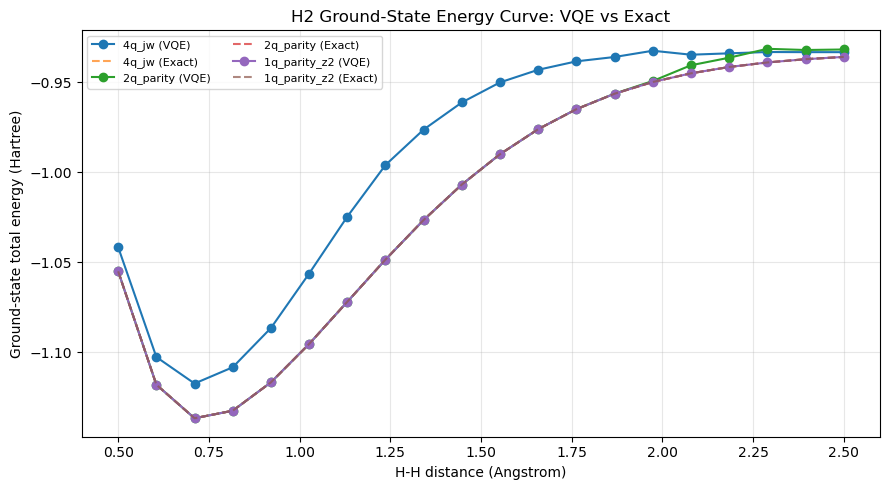

,hamiltonian,num_qubits,mean_abs_error,max_abs_error,mean_eval_count
2,4q_jw,4,2.522873e-02,5.254063e-02,120.00
1,2q_parity,2,1.353212e-03,7.575913e-03,102.55
0,1q_parity_z2,1,3.895955e-10,1.432185e-09,35.95


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
 )

distances = np.linspace(0.5, 2.5, 20)
basis = "sto-3g"
active_space = (2, 2)

rows = []
for d in distances:
    atom = f"H 0 0 0; H 0 0 {d}"

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    qubit_ops = {
        "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
        "2q_parity": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=False,
            problem=problem,
            num_particles=problem.num_particles,
        ),
        "1q_parity_z2": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=True,
            problem=problem,
            num_particles=problem.num_particles,
        ),
    }

    for label, qop in qubit_ops.items():
        ansatz = build_ansatz(
            name="real_amplitudes",
            num_qubits=qop.num_qubits,
            reps=2,
        )
        optimizer = get_optimizer("cobyla", max_iter=120)

        vqe_res = run_vqe(
            qubit_op=qop,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=float(const),
            seed=137,
        )

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
        exact_total = float(np.real(exact.eigenvalue) + float(const))

        rows.append({
            "distance": float(d),
            "hamiltonian": label,
            "num_qubits": qop.num_qubits,
            "num_terms": len(pauli_terms_from_qubit_hamiltonian(qop)),
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_total_energy": exact_total,
            "abs_error": abs(float(vqe_res["energy"]) - exact_total),
            "eval_count": int(vqe_res["eval_count"]),
        })

df = pd.DataFrame(rows)
display(df.head(9))

plt.figure(figsize=(9, 5))
for label in df["hamiltonian"].unique():
    sub = df[df["hamiltonian"] == label].sort_values("distance")
    plt.plot(sub["distance"], sub["vqe_total_energy"], marker="o", label=f"{label} (VQE)")
    plt.plot(sub["distance"], sub["exact_total_energy"], linestyle="--", alpha=0.7, label=f"{label} (Exact)")

plt.xlabel("H-H distance (Angstrom)")
plt.ylabel("Ground-state total energy (Hartree)")
plt.title("H2 Ground-State Energy Curve: VQE vs Exact")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

summary = (
    df.groupby(["hamiltonian", "num_qubits"], as_index=False)
    .agg(
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_eval_count=("eval_count", "mean"),
    )
    .sort_values("num_qubits", ascending=False)
)
display(summary)

## Comparison with PySCF FCI Curve (same distance points)

Here we load the cached FCI data generated in the other notebook (`00_fci_cache_baseline.ipynb`) for `H2/sto-3g`, and recompute VQE/exact energies on the **same FCI distances** (no interpolation).

This gives a fair point-by-point comparison against the PySCF FCI reference.

Using FCI cache file: fci_a29985a3fb.csv
FCI distance range: (0.34375, 2.0625)


,distance,hamiltonian,num_qubits,num_terms,fci_pyscf_energy,vqe_total_energy,exact_total_energy,vqe_vs_fci_abs_error,exact_vs_fci_abs_error,eval_count
0,0.343750,4q_jw,4,15,-0.769849,-0.761123,-0.769849,8.726313e-03,1.332268e-15,120
1,0.343750,2q_parity,2,5,-0.769849,-0.769849,-0.769849,4.286542e-09,4.440892e-16,57
2,0.343750,1q_parity_z2,1,3,-0.769849,-0.769849,-0.769849,1.275395e-09,2.220446e-15,37
3,0.361111,4q_jw,4,15,-0.821464,-0.812375,-0.821464,9.088818e-03,4.884981e-15,120
4,0.361111,2q_parity,2,5,-0.821464,-0.821464,-0.821464,6.745839e-09,3.108624e-15,72
5,0.361111,1q_parity_z2,1,3,-0.821464,-0.821464,-0.821464,9.171059e-10,1.776357e-15,34
6,0.378472,4q_jw,4,15,-0.866377,-0.856688,-0.866377,9.688408e-03,1.776357e-15,120
7,0.378472,2q_parity,2,5,-0.866377,-0.866377,-0.866377,7.701941e-10,5.329071e-15,64
8,0.378472,1q_parity_z2,1,3,-0.866377,-0.866377,-0.866377,1.136696e-09,3.108624e-15,39


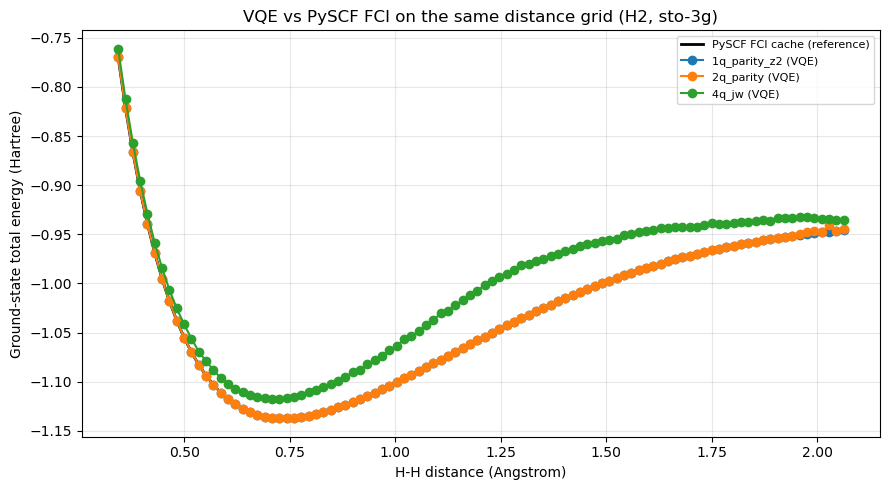

,hamiltonian,num_qubits,mean_vqe_vs_fci_error,max_vqe_vs_fci_error,mean_exact_vs_fci_error,max_exact_vs_fci_error,mean_eval_count
2,4q_jw,4,2.961466e-02,5.406981e-02,1.851852e-15,6.661338e-15,120.00
1,2q_parity,2,1.562599e-04,6.855073e-03,1.119105e-15,5.329071e-15,97.66
0,1q_parity_z2,1,5.855692e-10,5.352185e-09,9.992007e-16,3.108624e-15,37.37


In [8]:
from pathlib import Path

from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
 )

# Resolve project root whether notebook cwd is root or notebooks/
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data").exists() else cwd.parent

fci_dir = project_root / "data" / "H2" / "sto-3g"
fci_files = sorted(fci_dir.glob("fci_*.csv"), key=lambda p: p.stat().st_mtime)
if not fci_files:
    raise FileNotFoundError(f"No FCI cache files found in {fci_dir}")

fci_file = fci_files[-1]
fci_df = pd.read_csv(fci_file).sort_values("distance").reset_index(drop=True)

print("Using FCI cache file:", fci_file.name)
print("FCI distance range:", (float(fci_df["distance"].min()), float(fci_df["distance"].max())))

basis = "sto-3g"
active_space = (2, 2)

# Leave as None to use all FCI points (fair comparison).
max_points = None
if max_points is None:
    distances_eval = fci_df["distance"].values
else:
    distances_eval = fci_df["distance"].values[:max_points]

rows_fair = []
for d in distances_eval:
    atom = f"H 0 0 0; H 0 0 {float(d)}"

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    qubit_ops = {
        "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
        "2q_parity": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=False,
            problem=problem,
            num_particles=problem.num_particles,
        ),
        "1q_parity_z2": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=True,
            problem=problem,
            num_particles=problem.num_particles,
        ),
    }

    fci_ref = float(fci_df.loc[np.isclose(fci_df["distance"].values, d), "energy"].iloc[0])

    for label, qop in qubit_ops.items():
        ansatz = build_ansatz(
            name="real_amplitudes",
            num_qubits=qop.num_qubits,
            reps=2,
        )
        optimizer = get_optimizer("cobyla", max_iter=120)

        vqe_res = run_vqe(
            qubit_op=qop,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=float(const),
            seed=137,
        )

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
        exact_total = float(np.real(exact.eigenvalue) + float(const))

        rows_fair.append({
            "distance": float(d),
            "hamiltonian": label,
            "num_qubits": qop.num_qubits,
            "num_terms": len(pauli_terms_from_qubit_hamiltonian(qop)),
            "fci_pyscf_energy": fci_ref,
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_total_energy": exact_total,
            "vqe_vs_fci_abs_error": abs(float(vqe_res["energy"]) - fci_ref),
            "exact_vs_fci_abs_error": abs(exact_total - fci_ref),
            "eval_count": int(vqe_res["eval_count"]),
        })

compare_fair = pd.DataFrame(rows_fair)
display(compare_fair.head(9))

plt.figure(figsize=(9, 5))
fci_plot = fci_df[fci_df["distance"].isin(distances_eval)]
plt.plot(
    fci_plot["distance"],
    fci_plot["energy"],
    color="black",
    linewidth=2,
    label="PySCF FCI cache (reference)",
 )

for label in sorted(compare_fair["hamiltonian"].unique()):
    sub = compare_fair[compare_fair["hamiltonian"] == label].sort_values("distance")
    plt.plot(sub["distance"], sub["vqe_total_energy"], marker="o", label=f"{label} (VQE)")

plt.xlabel("H-H distance (Angstrom)")
plt.ylabel("Ground-state total energy (Hartree)")
plt.title("VQE vs PySCF FCI on the same distance grid (H2, sto-3g)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

fci_summary_fair = (
    compare_fair.groupby(["hamiltonian", "num_qubits"], as_index=False)
    .agg(
        mean_vqe_vs_fci_error=("vqe_vs_fci_abs_error", "mean"),
        max_vqe_vs_fci_error=("vqe_vs_fci_abs_error", "max"),
        mean_exact_vs_fci_error=("exact_vs_fci_abs_error", "mean"),
        max_exact_vs_fci_error=("exact_vs_fci_abs_error", "max"),
        mean_eval_count=("eval_count", "mean"),
    )
    .sort_values("num_qubits", ascending=False)
)
display(fci_summary_fair)

## VQE Fourier Analysis

This section performs a Fourier analysis of the VQE energy curve as a function of the bond distance. We extract the Fourier coefficients and analyze how they vary with distance, providing insight into the structure of the energy landscape.

### $H_2$

Distance = 0.74 A
Num qubits after tapering = 1
Pauli terms: SparsePauliOp(['I', 'Z', 'X'],
              coeffs=[-1.04217492+0.j, -0.78968873+0.j, -0.18121046+0.j])
Using n_harmonics = 3
RMSE = 1.823e-16 Ha
Max |error| = 6.661e-16 Ha


,k,a_k,b_k,amplitude
0,1,-7.896887e-01,-1.812105e-01,8.102133e-01
127,128,-1.110223e-16,-0.000000e+00,1.110223e-16
23,24,-1.811843e-17,7.744196e-17,7.953323e-17
24,25,7.653152e-17,1.877819e-17,7.880161e-17
64,65,7.632783e-17,-6.938894e-18,7.664259e-17
22,23,-5.550302e-17,2.856973e-17,6.242447e-17
62,63,3.469447e-17,-4.857226e-17,5.969062e-17
126,127,-5.551115e-17,-0.000000e+00,5.551115e-17
47,48,1.626730e-17,-4.876196e-17,5.140383e-17
15,16,-4.713387e-17,1.851421e-17,5.063968e-17


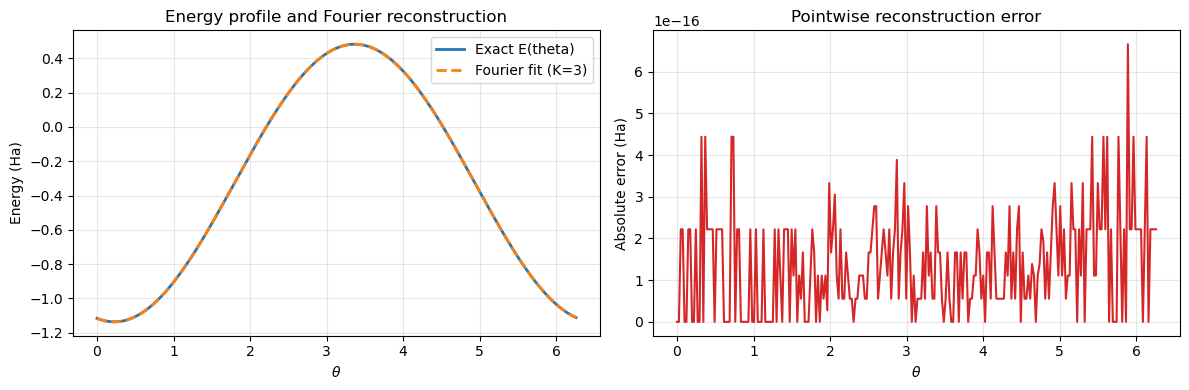

min exact sampled E = -1.13727499 Ha at theta = 0.2209
min fit E          = -1.13727499 Ha at theta = 0.2209


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import Statevector

from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

# --- 1) Build a 1-qubit effective Hamiltonian for H2 at fixed distance ---
distance = 0.74
basis = "sto-3g"
atom = f"H 0 0 0; H 0 0 {distance}"

problem = build_electronic_problem(
    atom_string=atom,
    basis=basis,
    active_space=(2, 2),
    freeze_core=False,
)

ferm_op, const_energy = build_electronic_hamiltonian(
    atom_string=atom,
    basis=basis,
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op = build_qubit_hamiltonian(
    ferm_op,
    mapper="parity",
    z2symmetry_reduction=True,
    problem=problem,
    num_particles=problem.num_particles,
).simplify()

print(f"Distance = {distance:.2f} A")
print(f"Num qubits after tapering = {qubit_op.num_qubits}")
print("Pauli terms:", qubit_op)

# --- 2) Define a one-parameter trial state and sample E(theta) ---
theta = Parameter("theta")
ansatz_1p = QuantumCircuit(qubit_op.num_qubits)
ansatz_1p.ry(theta, 0)

def energy_theta(theta_value: float) -> float:
    state = Statevector.from_instruction(
        ansatz_1p.assign_parameters({theta: float(theta_value)})
    )
    return float(np.real(state.expectation_value(qubit_op)) + const_energy)

N = 256
theta_grid = np.linspace(0, 2 * np.pi, N, endpoint=False)
energy_samples = np.array([energy_theta(t) for t in theta_grid])

# --- 3) Discrete Fourier transform: E(theta) ~ a0/2 + sum_k [a_k cos(k theta) + b_k sin(k theta)] ---
fft_r = np.fft.rfft(energy_samples) / N
a0 = 2.0 * fft_r[0].real
ak_all = 2.0 * fft_r[1:].real
bk_all = -2.0 * fft_r[1:].imag

def fourier_reconstruct(theta_values: np.ndarray, n_harmonics: int) -> np.ndarray:
    n_harmonics = max(1, min(n_harmonics, len(ak_all)))
    rec = np.full(theta_values.shape, a0 / 2.0, dtype=float)
    k = np.arange(1, n_harmonics + 1)[:, None]
    rec += (
        ak_all[:n_harmonics, None] * np.cos(k * theta_values)
        + bk_all[:n_harmonics, None] * np.sin(k * theta_values)
    ).sum(axis=0)
    return rec

n_harmonics = 3
energy_fit = fourier_reconstruct(theta_grid, n_harmonics=n_harmonics)

rmse = float(np.sqrt(np.mean((energy_samples - energy_fit) ** 2)))
max_abs_err = float(np.max(np.abs(energy_samples - energy_fit)))

print(f"Using n_harmonics = {n_harmonics}")
print(f"RMSE = {rmse:.3e} Ha")
print(f"Max |error| = {max_abs_err:.3e} Ha")

coef_df = pd.DataFrame(
    {
        "k": np.arange(1, len(ak_all) + 1),
        "a_k": ak_all,
        "b_k": bk_all,
        "amplitude": np.sqrt(ak_all**2 + bk_all**2),
    }
).sort_values("amplitude", ascending=False)

display(coef_df.head(10))

# --- 4) Plot exact samples vs truncated Fourier series ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(theta_grid, energy_samples, lw=2, label="Exact E(theta)")
ax[0].plot(theta_grid, energy_fit, "--", lw=2, label=f"Fourier fit (K={n_harmonics})")
ax[0].set_xlabel(r"$\theta$")
ax[0].set_ylabel("Energy (Ha)")
ax[0].set_title("Energy profile and Fourier reconstruction")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(theta_grid, np.abs(energy_samples - energy_fit), color="tab:red")
ax[1].set_xlabel(r"$\theta$")
ax[1].set_ylabel("Absolute error (Ha)")
ax[1].set_title("Pointwise reconstruction error")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: estimated minima from exact sampled curve and Fourier fit
idx_exact = int(np.argmin(energy_samples))
idx_fit = int(np.argmin(energy_fit))
print(f"min exact sampled E = {energy_samples[idx_exact]:.8f} Ha at theta = {theta_grid[idx_exact]:.4f}")
print(f"min fit E          = {energy_fit[idx_fit]:.8f} Ha at theta = {theta_grid[idx_fit]:.4f}")

LiH Kandala-like Fourier setup:
{'distance': 1.6, 'basis': 'sto-3g', 'active_space': (2, 3), 'active_orbitals': [0, 1, 2], 'freeze_core': True, 'mapper': 'bk', 'z2': True, 'num_qubits': 3, 'num_terms': 34, 'constant_energy': -6.804012298302051}
VQE local minimum estimate: -7.862917910188546
Scanned parameter: θ[0] around VQE optimum
Using n_harmonics = 8
RMSE = 5.295e-16 Ha
Max |error| = 1.776e-15 Ha


,k,a_k,b_k,amplitude
0,1,-3.928335e-01,-5.141394e-05,3.928335e-01
100,101,5.442308e-17,8.466984e-17,1.006521e-16
16,17,8.829181e-18,9.896693e-17,9.935999e-17
66,67,-3.403492e-17,-8.488283e-17,9.145201e-17
104,105,-6.587408e-17,4.826666e-17,8.166434e-17
94,95,6.959336e-17,4.258180e-17,8.158704e-17
38,39,-9.393295e-18,-7.788537e-17,7.844976e-17
116,117,1.751776e-18,7.776191e-17,7.778164e-17
36,37,6.637816e-17,3.910750e-17,7.704191e-17
12,13,-6.684974e-17,-3.248102e-17,7.432297e-17


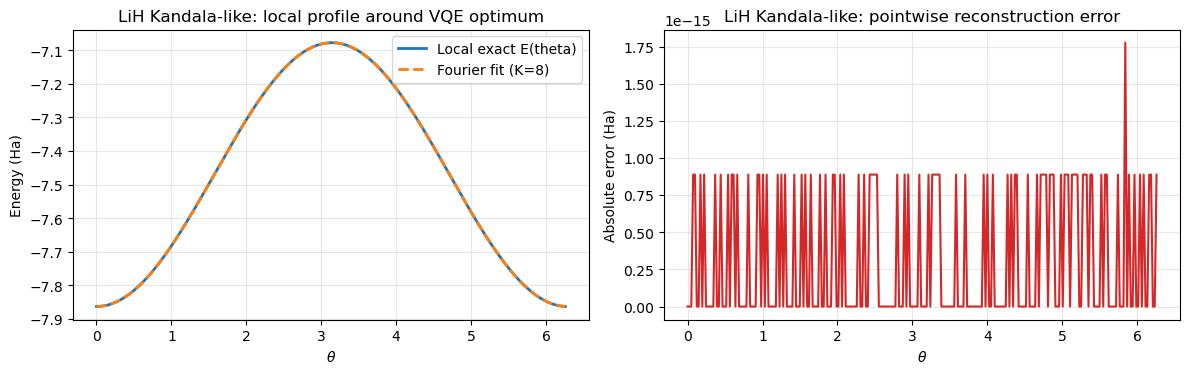

min exact sampled E = -7.86291791 Ha at theta = 0.0000
min fit E          = -7.86291791 Ha at theta = 0.0000


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

# --- LiH (Kandala-like) setup ---
distance_lih = 1.60
atom_lih = f"Li 0 0 0; H 0 0 {distance_lih}"
basis_lih = "sto-3g"
active_space_lih = (2, 3)
active_orbitals_lih = [0, 1, 2]
freeze_core_lih = True
mapper_lih = "bk"
z2_lih = True
ansatz_name_lih = "real_amplitudes"
ansatz_reps_lih = 4

problem_lih = build_electronic_problem(
    atom_string=atom_lih,
    basis=basis_lih,
    active_space=active_space_lih,
    active_orbitals=active_orbitals_lih,
    freeze_core=freeze_core_lih,
)

ferm_op_lih, const_lih = build_electronic_hamiltonian(
    atom_string=atom_lih,
    basis=basis_lih,
    active_space=active_space_lih,
    active_orbitals=active_orbitals_lih,
    freeze_core=freeze_core_lih,
)

qubit_op_lih = build_qubit_hamiltonian(
    ferm_op_lih,
    mapper=mapper_lih,
    z2symmetry_reduction=z2_lih,
    problem=problem_lih,
    num_particles=problem_lih.num_particles,
).simplify(atol=0.0)

terms_lih = pauli_terms_from_qubit_hamiltonian(qubit_op_lih, tolerance=1e-12)

print("LiH Kandala-like Fourier setup:")
print({
    "distance": distance_lih,
    "basis": basis_lih,
    "active_space": active_space_lih,
    "active_orbitals": active_orbitals_lih,
    "freeze_core": freeze_core_lih,
    "mapper": mapper_lih,
    "z2": z2_lih,
    "num_qubits": int(qubit_op_lih.num_qubits),
    "num_terms": int(len(terms_lih)),
    "constant_energy": float(const_lih),
})

# --- VQE point for a meaningful local Fourier cut ---
ansatz_lih = build_ansatz(
    name=ansatz_name_lih,
    num_qubits=qubit_op_lih.num_qubits,
    reps=ansatz_reps_lih,
  )
optimizer_lih = get_optimizer("cobyla", max_iter=400)
vqe_probe = run_vqe(
    qubit_op=qubit_op_lih,
    ansatz=ansatz_lih,
    optimizer=optimizer_lih,
    constant_energy=float(const_lih),
    seed=137,
)
if not vqe_probe.get("success", False):
    raise RuntimeError(f"VQE probe failed: {vqe_probe.get('error', 'unknown error')}")

p_star = np.asarray(vqe_probe["optimal_params"], dtype=float)
print("VQE local minimum estimate:", float(vqe_probe["energy"]))

# Use first parameter as scan direction around the optimized point
param_list = list(ansatz_lih.parameters)
if not param_list:
    raise RuntimeError("Ansatz has no parameters for Fourier analysis.")

theta_param = param_list[0]
param_index = 0

def wrap_pi(x: np.ndarray) -> np.ndarray:
    return ((x + np.pi) % (2 * np.pi)) - np.pi

def energy_theta_lih(theta_value: float) -> float:
    p = p_star.copy()
    p[param_index] = p_star[param_index] + float(theta_value)
    p = wrap_pi(p)
    bind = {param_list[i]: float(p[i]) for i in range(len(param_list))}
    state = Statevector.from_instruction(ansatz_lih.assign_parameters(bind))
    return float(np.real(state.expectation_value(qubit_op_lih)) + float(const_lih))

N = 256
theta_grid = np.linspace(0, 2 * np.pi, N, endpoint=False)
energy_samples = np.array([energy_theta_lih(t) for t in theta_grid])

# E(theta) ~ a0/2 + sum_k [a_k cos(k theta) + b_k sin(k theta)]
fft_r = np.fft.rfft(energy_samples) / N
a0 = 2.0 * fft_r[0].real
ak_all = 2.0 * fft_r[1:].real   
bk_all = -2.0 * fft_r[1:].imag

def fourier_reconstruct(theta_values: np.ndarray, n_harmonics: int) -> np.ndarray:
    n_harmonics = max(1, min(n_harmonics, len(ak_all)))
    rec = np.full(theta_values.shape, a0 / 2.0, dtype=float)
    k = np.arange(1, n_harmonics + 1)[:, None]
    rec += (
        ak_all[:n_harmonics, None] * np.cos(k * theta_values)
        + bk_all[:n_harmonics, None] * np.sin(k * theta_values)
    ).sum(axis=0)
    return rec

n_harmonics = 8
energy_fit = fourier_reconstruct(theta_grid, n_harmonics=n_harmonics)

rmse = float(np.sqrt(np.mean((energy_samples - energy_fit) ** 2)))
max_abs_err = float(np.max(np.abs(energy_samples - energy_fit)))

print(f"Scanned parameter: {theta_param} around VQE optimum")
print(f"Using n_harmonics = {n_harmonics}")
print(f"RMSE = {rmse:.3e} Ha")
print(f"Max |error| = {max_abs_err:.3e} Ha")

coef_df_lih = pd.DataFrame(
    {
        "k": np.arange(1, len(ak_all) + 1),
        "a_k": ak_all,
        "b_k": bk_all,
        "amplitude": np.sqrt(ak_all**2 + bk_all**2),
    }
).sort_values("amplitude", ascending=False)
display(coef_df_lih.head(12))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(theta_grid, energy_samples, lw=2, label="Local exact E(theta)")
ax[0].plot(theta_grid, energy_fit, "--", lw=2, label=f"Fourier fit (K={n_harmonics})")
ax[0].set_xlabel(r"$\theta$")
ax[0].set_ylabel("Energy (Ha)")
ax[0].set_title("LiH Kandala-like: local profile around VQE optimum")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(theta_grid, np.abs(energy_samples - energy_fit), color="tab:red")
ax[1].set_xlabel(r"$\theta$")
ax[1].set_ylabel("Absolute error (Ha)")
ax[1].set_title("LiH Kandala-like: pointwise reconstruction error")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

idx_exact = int(np.argmin(energy_samples))
idx_fit = int(np.argmin(energy_fit))
print(f"min exact sampled E = {energy_samples[idx_exact]:.8f} Ha at theta = {theta_grid[idx_exact]:.4f}")
print(f"min fit E          = {energy_fit[idx_fit]:.8f} Ha at theta = {theta_grid[idx_fit]:.4f}")

### Fourier Coefficients vs Distance (Multi-direction, Step 1)

This section performs a distance sweep and extracts Fourier coefficients from
local 1D cuts in parameter space around the VQE optimum.

A simple toggle selects the molecule (`"LiH"` or `"H2"`).

For each distance, we:
1. run VQE to get an approximate optimum $\mathbf{p}^*$,
2. sample multiple directions $\mathbf{v}_j$ (unit vectors),
3. evaluate $E(\theta)$ along $\mathbf{p}(\theta)=\mathbf{p}^*+\theta\mathbf{v}_j$,
4. fit the first harmonic
$$
E(\theta) \approx \frac{a_0}{2}+a_1\cos\theta+b_1\sin\theta,
$$
and compare its predicted minimum against the sampled minimum.

The goal is to identify directions where a low-order Fourier model is most predictive.

Active Fourier experiment config:
{'toggle': 'LiH', 'molecule': 'LiH', 'bond': 'Li-H', 'basis': 'sto-3g', 'active_space': (2, 3), 'active_orbitals': [0, 1, 2], 'freeze_core': True, 'mapper': 'bk', 'z2': True, 'ansatz_name': 'real_amplitudes', 'ansatz_reps': 4, 'n_distances': 14, 'distance_min': 0.5, 'distance_max': 2.5}


,molecule,distance,direction_id,num_qubits,num_terms,exact_total,vqe_probe_total,a0_half,a1,b1,amp1,theta_min_h1,theta_min_exact,e_min_h1,e_min_exact,abs_err_min,rmse_h1
0,LiH,0.500000,0,3,34,-7.033796,-7.032369,-6.732795,-0.299574,0.001422,0.299577,6.278439,0.0,-7.032373,-7.032369,3.374816e-06,4.710277e-16
1,LiH,0.500000,1,3,34,-7.033796,-7.032369,-6.849823,-0.148264,0.058768,0.159486,5.905806,0.0,-7.009310,-7.032369,2.305973e-02,3.711391e-02
3,LiH,0.500000,3,3,34,-7.033796,-7.032369,-6.843055,-0.130733,0.044273,0.138026,5.956658,0.0,-6.981081,-7.032369,5.128784e-02,2.092570e-02
4,LiH,0.500000,4,3,34,-7.033796,-7.032369,-6.756517,-0.108091,0.130853,0.169724,5.402812,0.0,-6.926241,-7.032369,1.061281e-01,1.028944e-01
2,LiH,0.500000,2,3,34,-7.033796,-7.032369,-6.848562,-0.040954,-0.064404,0.076322,1.004402,0.0,-6.924885,-7.032369,1.074847e-01,6.173004e-02
5,LiH,0.653846,0,3,34,-7.410554,-7.410519,-6.998454,-0.412065,0.000814,0.412066,6.281209,0.0,-7.410520,-7.410519,8.047885e-07,9.155134e-16
7,LiH,0.653846,2,3,34,-7.410554,-7.410519,-7.244630,0.040963,-0.160153,0.165309,1.821199,0.0,-7.409938,-7.410519,5.805673e-04,8.688002e-02
8,LiH,0.653846,3,3,34,-7.410554,-7.410519,-7.067484,-0.094926,-0.206485,0.227260,1.139885,0.0,-7.294744,-7.410519,1.157753e-01,8.828529e-02
6,LiH,0.653846,1,3,34,-7.410554,-7.410519,-7.054179,-0.070649,-0.173295,0.187143,1.183687,0.0,-7.241322,-7.410519,1.691972e-01,1.392594e-01
9,LiH,0.653846,4,3,34,-7.410554,-7.410519,-6.821687,-0.162948,-0.152788,0.223374,0.753230,0.0,-7.045061,-7.410519,3.654575e-01,1.928542e-01


,distance,direction_id,amp1,abs_err_min,rmse_h1,e_min_exact,e_min_h1
0,0.500000,0,0.299577,3.374816e-06,4.710277e-16,-7.032369,-7.032373
1,0.653846,0,0.412066,8.047885e-07,9.155134e-16,-7.410519,-7.410520
2,0.807692,0,0.555579,2.057965e-06,6.661338e-16,-7.625453,-7.625455
3,0.961538,0,0.430951,1.055423e-06,5.874748e-16,-7.747715,-7.747716
4,1.115385,0,0.335724,1.352213e-07,5.207408e-16,-7.814864,-7.814864
5,1.269231,0,0.319382,2.538842e-08,5.978734e-16,-7.848947,-7.848947
6,1.423077,0,0.400538,2.005438e-07,5.324443e-16,-7.862639,-7.862639
7,1.576923,0,0.393732,2.586121e-06,1.017536e-15,-7.863549,-7.863552
8,1.730769,0,0.552412,3.632242e-06,5.324443e-16,-7.856175,-7.856178
9,1.884615,0,0.446101,1.332022e-06,8.671119e-16,-7.842723,-7.842724


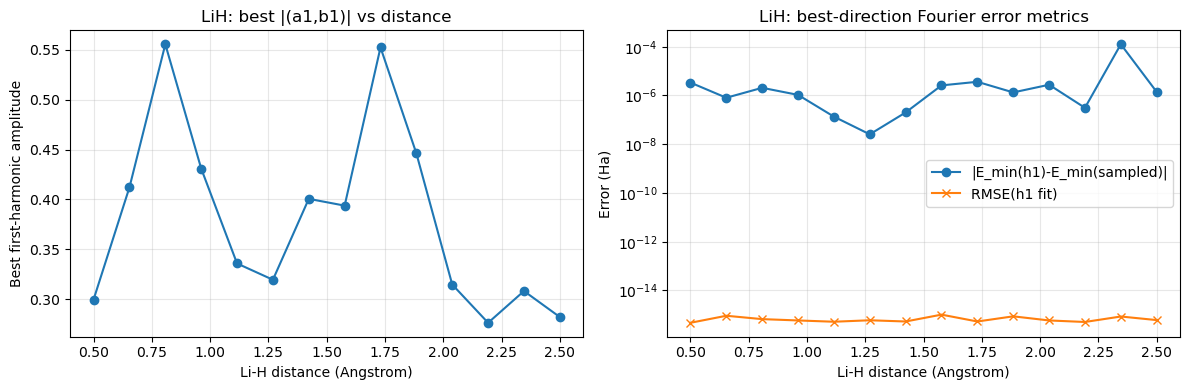

Toggle: LiH
Mean best-direction |E_min(h1)-E_min(sampled)|: 1.040104901691866e-05
Max  best-direction |E_min(h1)-E_min(sampled)|: 0.00012595249861746538


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
 )

rng = np.random.default_rng(2026)

# Toggle: choose "LiH" or "H2"
molecule_toggle = "LiH"

if molecule_toggle == "LiH":
    molecule_label = "LiH"
    bond_label = "Li-H"
    basis = "sto-3g"
    active_space = (2, 3)
    active_orbitals = [0, 1, 2]
    freeze_core = True
    mapper = "bk"
    z2 = True
    ansatz_name = "real_amplitudes"
    ansatz_reps = 4
    distances_scan = np.linspace(0.5, 2.5, 14)

    def make_atom(d: float) -> str:
        return f"Li 0 0 0; H 0 0 {float(d)}"
elif molecule_toggle == "H2":
    molecule_label = "H2"
    bond_label = "H-H"
    basis = "sto-3g"
    active_space = (2, 2)
    active_orbitals = None
    freeze_core = False
    mapper = "parity"
    z2 = True
    ansatz_name = "real_amplitudes"
    ansatz_reps = 2
    distances_scan = np.linspace(0.5, 2.5, 14)

    def make_atom(d: float) -> str:
        return f"H 0 0 0; H 0 0 {float(d)}"
else:
    raise ValueError("molecule_toggle must be 'LiH' or 'H2'.")

print("Active Fourier experiment config:")
print(
    {
        "toggle": molecule_toggle,
        "molecule": molecule_label,
        "bond": bond_label,
        "basis": basis,
        "active_space": active_space,
        "active_orbitals": active_orbitals,
        "freeze_core": freeze_core,
        "mapper": mapper,
        "z2": z2,
        "ansatz_name": ansatz_name,
        "ansatz_reps": ansatz_reps,
        "n_distances": int(len(distances_scan)),
        "distance_min": float(np.min(distances_scan)),
        "distance_max": float(np.max(distances_scan)),
    }
)

N_theta = 64
theta_grid = np.linspace(0.0, 2.0 * np.pi, N_theta, endpoint=False)
n_random_directions = 4

def wrap_pi(x: np.ndarray) -> np.ndarray:
    return ((x + np.pi) % (2 * np.pi)) - np.pi

rows_fourier = []
fourier_guidance = {}

for d in distances_scan:
    atom = make_atom(float(d))

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )

    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )

    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper=mapper,
        z2symmetry_reduction=z2,
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify(atol=0.0)

    ansatz = build_ansatz(
        name=ansatz_name,
        num_qubits=qubit_op.num_qubits,
        reps=ansatz_reps,
    )
    param_list = list(ansatz.parameters)
    n_params = len(param_list)
    if n_params == 0:
        raise RuntimeError("Ansatz has no parameters for Fourier direction scan.")

    optimizer = get_optimizer("cobyla", max_iter=300)
    vqe_probe = run_vqe(
        qubit_op=qubit_op,
        ansatz=ansatz,
        optimizer=optimizer,
        constant_energy=float(const_energy),
        seed=137,
    )
    if not vqe_probe.get("success", False):
        raise RuntimeError(f"VQE probe failed at d={d:.3f}: {vqe_probe.get('error', 'unknown error')}")

    p_star = np.asarray(vqe_probe["optimal_params"], dtype=float)
    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    exact_total = float(np.real(exact.eigenvalue) + float(const_energy))

    directions = [np.eye(n_params)[0]]
    for _ in range(n_random_directions):
        v = rng.normal(size=n_params)
        norm = float(np.linalg.norm(v))
        if norm < 1e-12:
            continue
        directions.append(v / norm)

    best_row = None
    for j, v in enumerate(directions):
        v = np.asarray(v, dtype=float)

        def energy_theta(theta_value: float) -> float:
            p = wrap_pi(p_star + float(theta_value) * v)
            bind = {param_list[i]: float(p[i]) for i in range(n_params)}
            state = Statevector.from_instruction(ansatz.assign_parameters(bind))
            return float(np.real(state.expectation_value(qubit_op)) + float(const_energy))

        energy_samples = np.array([energy_theta(t) for t in theta_grid])

        fft_r = np.fft.rfft(energy_samples) / N_theta
        a0_half = float(fft_r[0].real)
        if len(fft_r) > 1:
            a1 = float(2.0 * fft_r[1].real)
            b1 = float(-2.0 * fft_r[1].imag)
        else:
            a1, b1 = 0.0, 0.0

        amp1 = float(np.sqrt(a1**2 + b1**2))
        theta_min_h1 = float((np.arctan2(b1, a1) + np.pi) % (2 * np.pi))
        e_min_h1 = float(a0_half - amp1)

        idx_exact = int(np.argmin(energy_samples))
        theta_min_exact = float(theta_grid[idx_exact])
        e_min_exact = float(energy_samples[idx_exact])

        abs_err_min = float(abs(e_min_h1 - e_min_exact))
        rmse_h1 = float(np.sqrt(np.mean((energy_samples - (a0_half + a1 * np.cos(theta_grid) + b1 * np.sin(theta_grid))) ** 2)))

        row_j = {
            "molecule": molecule_label,
            "distance": float(d),
            "direction_id": int(j),
            "num_qubits": int(qubit_op.num_qubits),
            "num_terms": int(len(pauli_terms_from_qubit_hamiltonian(qubit_op, tolerance=1e-12))),
            "exact_total": exact_total,
            "vqe_probe_total": float(vqe_probe["energy"]),
            "a0_half": a0_half,
            "a1": a1,
            "b1": b1,
            "amp1": amp1,
            "theta_min_h1": theta_min_h1,
            "theta_min_exact": theta_min_exact,
            "e_min_h1": e_min_h1,
            "e_min_exact": e_min_exact,
            "abs_err_min": abs_err_min,
            "rmse_h1": rmse_h1,
        }
        rows_fourier.append(row_j)

        if best_row is None or row_j["abs_err_min"] < best_row["abs_err_min"]:
            best_row = row_j

    fourier_guidance[float(d)] = {
        "p_star": p_star.copy(),
        "best_direction": np.asarray(directions[best_row["direction_id"]], dtype=float).copy(),
        "theta_min_h1": float(best_row["theta_min_h1"]),
        "best_abs_err_min": float(best_row["abs_err_min"]),
        "n_params": int(n_params),
    }

# Persist config so Step 2 reuses the exact same setup
_fourier_experiment_cfg = {
    "molecule_toggle": molecule_toggle,
    "molecule_label": molecule_label,
    "bond_label": bond_label,
    "basis": basis,
    "active_space": active_space,
    "active_orbitals": active_orbitals,
    "freeze_core": freeze_core,
    "mapper": mapper,
    "z2": z2,
    "ansatz_name": ansatz_name,
    "ansatz_reps": ansatz_reps,
    "distances_scan": np.array(distances_scan, dtype=float),
}

fourier_df = pd.DataFrame(rows_fourier).sort_values(["distance", "abs_err_min"])
display(fourier_df.head(20))

best_per_distance = (
    fourier_df.sort_values(["distance", "abs_err_min"])
    .groupby("distance", as_index=False)
    .first()
    .sort_values("distance")
)

display(best_per_distance[["distance", "direction_id", "amp1", "abs_err_min", "rmse_h1", "e_min_exact", "e_min_h1"]])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(best_per_distance["distance"], best_per_distance["amp1"], marker="o")
ax[0].set_xlabel(f"{bond_label} distance (Angstrom)")
ax[0].set_ylabel("Best first-harmonic amplitude")
ax[0].set_title(f"{molecule_label}: best |(a1,b1)| vs distance")
ax[0].grid(alpha=0.3)

ax[1].plot(best_per_distance["distance"], best_per_distance["abs_err_min"], marker="o", label="|E_min(h1)-E_min(sampled)|")
ax[1].plot(best_per_distance["distance"], best_per_distance["rmse_h1"], marker="x", label="RMSE(h1 fit)")
ax[1].set_xlabel(f"{bond_label} distance (Angstrom)")
ax[1].set_ylabel("Error (Ha)")
ax[1].set_title(f"{molecule_label}: best-direction Fourier error metrics")
ax[1].set_yscale("log")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print("Toggle:", molecule_toggle)
print("Mean best-direction |E_min(h1)-E_min(sampled)|:", float(best_per_distance["abs_err_min"].mean()))
print("Max  best-direction |E_min(h1)-E_min(sampled)|:", float(best_per_distance["abs_err_min"].max()))

### Fourier-Guided Initialization vs Random vs Default (Step 2)

Using the guidance extracted in Step 1 (best direction and predicted $\theta_{\min}^{(h1)}$),
we build a guided initial point for the full parameter vector:
$$
\mathbf{p}_0^{\text{guided}} = \mathbf{p}^* + (\theta_{\min}^{(h1)} + \epsilon)\,\mathbf{v}_{\text{best}},
$$
with small Gaussian perturbation $\epsilon$.

The molecule setup is reused from the Step 1 toggle (`"LiH"` or `"H2"`).

We compare three initialization modes:
- `fourier_guided`: guided by local Fourier analysis,
- `random`: fully random initialization in $[-\pi,\pi]^{n_p}$,
- `default_none`: no `initial_point` argument (optimizer/backend default).

Metrics:
- optimizer evaluation count,
- absolute error against exact diagonalization.

,molecule,distance,mode,trial,success,vqe_energy,exact_energy,abs_error,eval_count
0,LiH,0.500000,fourier_guided,0,True,-7.033790,-7.033796,6.127672e-06,450.0
1,LiH,0.500000,random,0,True,-7.033792,-7.033796,4.183653e-06,450.0
2,LiH,0.500000,default_none,0,True,-7.033750,-7.033796,4.606336e-05,450.0
3,LiH,0.500000,fourier_guided,1,True,-7.033788,-7.033796,7.894313e-06,450.0
4,LiH,0.500000,random,1,True,-7.033794,-7.033796,1.717528e-06,450.0
5,LiH,0.500000,default_none,1,True,-7.033796,-7.033796,2.700493e-07,450.0
6,LiH,0.500000,fourier_guided,2,True,-7.033794,-7.033796,1.541357e-06,450.0
7,LiH,0.500000,random,2,True,-7.033657,-7.033796,1.389059e-04,450.0
8,LiH,0.500000,default_none,2,True,-7.033784,-7.033796,1.177849e-05,450.0
9,LiH,0.653846,fourier_guided,0,True,-7.410554,-7.410554,2.298114e-08,257.0


,mode,mean_eval_count,std_eval_count,mean_abs_error,max_abs_error,n_success
0,default_none,450.000000,0.000000,2.323237e-05,0.000171,42
1,fourier_guided,354.404762,77.088818,4.774213e-07,0.000008,42
2,random,446.333333,12.134745,2.291060e-04,0.005645,42


,distance,mode,mean_eval_count,mean_abs_error
0,0.500000,default_none,450.000000,1.937063e-05
1,0.500000,fourier_guided,450.000000,5.187781e-06
2,0.500000,random,450.000000,4.826902e-05
3,0.653846,default_none,450.000000,2.053217e-06
4,0.653846,fourier_guided,334.666667,2.550312e-08
5,0.653846,random,450.000000,3.623555e-06
6,0.807692,default_none,450.000000,1.382223e-06
7,0.807692,fourier_guided,303.333333,7.023246e-09
8,0.807692,random,416.333333,2.447816e-08
9,0.961538,default_none,450.000000,1.689950e-05


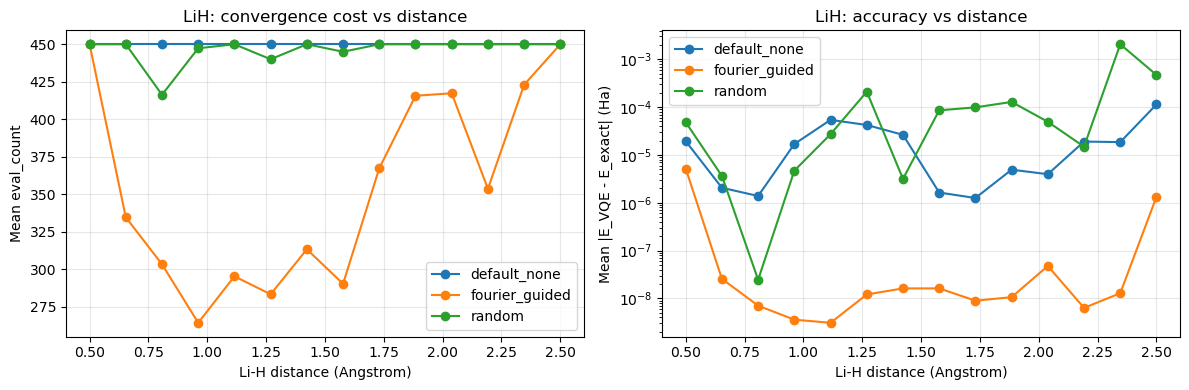

Toggle used in Step 1: LiH


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)

if "fourier_guidance" not in globals():
    raise RuntimeError("Run Step 1 first to generate fourier_guidance.")
if "_fourier_experiment_cfg" not in globals():
    raise RuntimeError("Run Step 1 first to define _fourier_experiment_cfg.")

cfg = _fourier_experiment_cfg
molecule_label = cfg["molecule_label"]
bond_label = cfg["bond_label"]
basis = cfg["basis"]
active_space = tuple(cfg["active_space"])
active_orbitals = cfg["active_orbitals"]
freeze_core = bool(cfg["freeze_core"])
mapper = cfg["mapper"]
z2 = bool(cfg["z2"])
ansatz_name = cfg["ansatz_name"]
ansatz_reps = int(cfg["ansatz_reps"])

if cfg["molecule_toggle"] == "LiH":
    def make_atom(d: float) -> str:
        return f"Li 0 0 0; H 0 0 {float(d)}"
else:
    def make_atom(d: float) -> str:
        return f"H 0 0 0; H 0 0 {float(d)}"

def wrap_pi(x: np.ndarray) -> np.ndarray:
    return ((x + np.pi) % (2 * np.pi)) - np.pi

rng = np.random.default_rng(3030)
trials_per_distance = 3
sigma_theta = 0.12

rows_init = []

for d in sorted(fourier_guidance.keys()):
    atom = make_atom(float(d))
    guide = fourier_guidance[float(d)]

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )
    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )

    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper=mapper,
        z2symmetry_reduction=z2,
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify(atol=0.0)

    ansatz = build_ansatz(
        name=ansatz_name,
        num_qubits=qubit_op.num_qubits,
        reps=ansatz_reps,
    )

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    exact_total = float(np.real(exact.eigenvalue) + float(const_energy))

    p_star = np.asarray(guide["p_star"], dtype=float)
    v_best = np.asarray(guide["best_direction"], dtype=float)
    theta_h1 = float(guide["theta_min_h1"])
    n_params = len(p_star)

    for trial in range(trials_per_distance):
        init_guided = wrap_pi(p_star + (theta_h1 + rng.normal(0.0, sigma_theta)) * v_best)
        init_random = rng.uniform(-np.pi, np.pi, size=n_params)

        init_modes = {
            "fourier_guided": init_guided,
            "random": init_random,
            "default_none": None,
        }

        for mode, init_point in init_modes.items():
            optimizer = get_optimizer("cobyla", max_iter=450)
            run_kwargs = {
                "qubit_op": qubit_op,
                "ansatz": ansatz,
                "optimizer": optimizer,
                "constant_energy": float(const_energy),
                "seed": 5000 + trial,
            }
            if init_point is not None:
                run_kwargs["initial_point"] = np.asarray(init_point, dtype=float)

            res = run_vqe(**run_kwargs)

            if not res.get("success", False):
                rows_init.append(
                    {
                        "molecule": molecule_label,
                        "distance": float(d),
                        "mode": mode,
                        "trial": int(trial),
                        "success": False,
                        "abs_error": np.nan,
                        "eval_count": np.nan,
                    }
                )
                continue

            rows_init.append(
                {
                    "molecule": molecule_label,
                    "distance": float(d),
                    "mode": mode,
                    "trial": int(trial),
                    "success": True,
                    "vqe_energy": float(res["energy"]),
                    "exact_energy": exact_total,
                    "abs_error": float(abs(float(res["energy"]) - exact_total)),
                    "eval_count": float(res["eval_count"]),
                }
            )

init_df = pd.DataFrame(rows_init)
display(init_df.head(20))

ok_df = init_df[init_df["success"] == True].copy()
if ok_df.empty:
    raise RuntimeError("All VQE runs failed in initialization comparison.")

summary_init = (
    ok_df.groupby("mode", as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        std_eval_count=("eval_count", "std"),
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        n_success=("success", "size"),
    )
)
display(summary_init)

per_distance = (
    ok_df.groupby(["distance", "mode"], as_index=False)
    .agg(
        mean_eval_count=("eval_count", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
    .sort_values(["distance", "mode"])
)
display(per_distance)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for mode, sub in per_distance.groupby("mode"):
    ax[0].plot(sub["distance"], sub["mean_eval_count"], marker="o", label=mode)
    ax[1].plot(sub["distance"], sub["mean_abs_error"], marker="o", label=mode)

ax[0].set_xlabel(f"{bond_label} distance (Angstrom)")
ax[0].set_ylabel("Mean eval_count")
ax[0].set_title(f"{molecule_label}: convergence cost vs distance")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].set_xlabel(f"{bond_label} distance (Angstrom)")
ax[1].set_ylabel("Mean |E_VQE - E_exact| (Ha)")
ax[1].set_title(f"{molecule_label}: accuracy vs distance")
ax[1].set_yscale("log")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print("Toggle used in Step 1:", cfg["molecule_toggle"])

,distance,ref_energy,exact_total_energy,vqe_default_energy,vqe_guided_energy,default_vs_ref_abs_error,guided_vs_ref_abs_error,default_eval_count,guided_eval_count,default_success,guided_success
0,0.500000,-7.050225,-7.033796,-7.033539,-7.033791,0.016686,0.016434,450,450,True,True
1,0.653846,-7.427656,-7.410554,-7.410429,-7.410554,0.017227,0.017102,450,450,True,True
2,0.807692,-7.642275,-7.625517,-7.625385,-7.625517,0.016890,0.016758,450,450,True,True
3,0.961538,-7.763735,-7.747746,-7.747721,-7.747746,0.016014,0.015989,450,298,True,True
4,1.115385,-7.830480,-7.814872,-7.814872,-7.814872,0.015609,0.015608,450,176,True,True
5,1.269231,-7.864897,-7.848956,-7.848953,-7.848956,0.015944,0.015941,450,337,True,True
6,1.423077,-7.879775,-7.862696,-7.862682,-7.862696,0.017093,0.017079,450,250,True,True
7,1.576923,-7.882621,-7.863582,-7.863401,-7.863582,0.019221,0.019039,450,450,True,True
8,1.730769,-7.878105,-7.856266,-7.856102,-7.856266,0.022003,0.021839,450,450,True,True
9,1.884615,-7.869275,-7.843764,-7.843510,-7.843764,0.025765,0.025511,450,450,True,True


,reference,mean_default_vs_ref_abs_error,mean_guided_vs_ref_abs_error,mean_default_eval_count,mean_guided_eval_count
0,FCI,0.025693,0.024198,450.0,397.214286


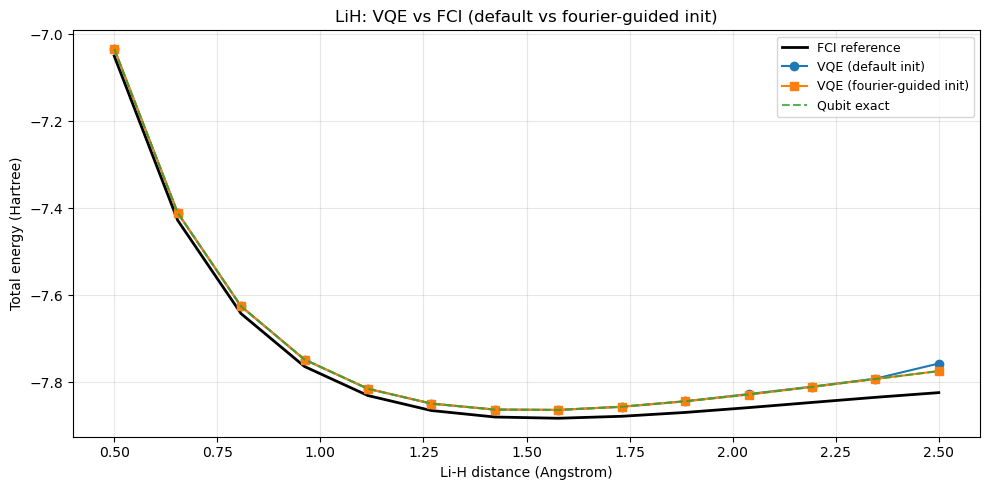

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from qiskit.quantum_info import Statevector
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
)
from src.data.cache import cache_fci

# --- LiH setup (aligned with previous sections) ---
molecule = "LiH"
bond_label = "Li-H"
basis = "sto-3g"
active_space = (2, 3)
active_orbitals = [0, 1, 2]
freeze_core = True
mapper = "parity"
z2 = True
ansatz_name = "real_amplitudes"
ansatz_reps = 3
optimizer_name = "cobyla"
optimizer_max_iter = 450
seed = 137

# If Step 1 ran with LiH, reuse the same grid; otherwise use default LiH grid.
if "_fourier_experiment_cfg" in globals() and _fourier_experiment_cfg.get("molecule_toggle") == "LiH":
    distances = np.array(_fourier_experiment_cfg["distances_scan"], dtype=float)
else:
    distances = np.array([1.2, 1.44, 1.68, 1.92, 2.16, 2.4], dtype=float)

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "src").exists() else cwd.parent

# Toggle for the reference: full FCI (active_space=None) or CASCI(active_space).
use_full_fci_reference = True

def _geom_lih(d: float) -> str:
    return f"Li 0 0 0; H 0 0 {float(d)}"

def _wrap_pi(x: np.ndarray) -> np.ndarray:
    return ((x + np.pi) % (2 * np.pi)) - np.pi

ref_energies = cache_fci(
    molecule=molecule,
    geometry_fn=_geom_lih,
    distances=distances,
    basis=basis,
    active_space=None if use_full_fci_reference else active_space,
    active_orbitals=None if use_full_fci_reference else active_orbitals,
    homo_lumo_window=2,
    freeze_core=0 if use_full_fci_reference else 1,
    data_dir=project_root / "data",
    overwrite=False,
    verbose=False,
 )
ref_kind = "FCI" if use_full_fci_reference else "CASCI"
ref_map = {float(d): float(e) for d, e in zip(distances, ref_energies)}

rows_compare = []
for d in distances:
    d = float(d)
    atom = _geom_lih(d)

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )
    ferm_op, const_energy = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        active_orbitals=active_orbitals,
        freeze_core=freeze_core,
    )
    qubit_op = build_qubit_hamiltonian(
        ferm_op,
        mapper=mapper,
        z2symmetry_reduction=z2,
        problem=problem,
        num_particles=problem.num_particles,
    ).simplify(atol=0.0)

    ansatz = build_ansatz(
        name=ansatz_name,
        num_qubits=qubit_op.num_qubits,
        reps=ansatz_reps,
    )
    param_list = list(ansatz.parameters)
    if not param_list:
        raise RuntimeError("Ansatz has no parameters for guided initialization.")

    # Probe VQE to build a local guided init from first-harmonic minimum on one direction.
    optimizer_probe = get_optimizer(optimizer_name, max_iter=optimizer_max_iter)
    probe_res = run_vqe(
        qubit_op=qubit_op,
        ansatz=ansatz,
        optimizer=optimizer_probe,
        constant_energy=float(const_energy),
        seed=seed,
    )
    if not probe_res.get("success", False):
        raise RuntimeError(f"Probe VQE failed at d={d:.3f}: {probe_res.get('error', 'unknown error')}")

    p_star = np.asarray(probe_res["optimal_params"], dtype=float)
    n_params = len(p_star)
    direction = np.eye(n_params)[0]

    theta_grid = np.linspace(0.0, 2.0 * np.pi, 64, endpoint=False)
    energies_line = []
    for t in theta_grid:
        p = _wrap_pi(p_star + float(t) * direction)
        bind = {param_list[i]: float(p[i]) for i in range(n_params)}
        state = Statevector.from_instruction(ansatz.assign_parameters(bind))
        energies_line.append(float(np.real(state.expectation_value(qubit_op)) + float(const_energy)))
    energies_line = np.asarray(energies_line, dtype=float)

    fft_r = np.fft.rfft(energies_line) / len(theta_grid)
    a1 = float(2.0 * fft_r[1].real) if len(fft_r) > 1 else 0.0
    b1 = float(-2.0 * fft_r[1].imag) if len(fft_r) > 1 else 0.0
    theta_min_h1 = float((np.arctan2(b1, a1) + np.pi) % (2 * np.pi))
    init_guided = _wrap_pi(p_star + theta_min_h1 * direction)

    # Run 1: default init (no initial_point).
    optimizer_default = get_optimizer(optimizer_name, max_iter=optimizer_max_iter)
    res_default = run_vqe(
        qubit_op=qubit_op,
        ansatz=ansatz,
        optimizer=optimizer_default,
        constant_energy=float(const_energy),
        seed=seed,
    )

    # Run 2: fourier-guided init.
    optimizer_guided = get_optimizer(optimizer_name, max_iter=optimizer_max_iter)
    res_guided = run_vqe(
        qubit_op=qubit_op,
        ansatz=ansatz,
        optimizer=optimizer_guided,
        initial_point=np.asarray(init_guided, dtype=float),
        constant_energy=float(const_energy),
        seed=seed,
    )

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    exact_total = float(np.real(exact.eigenvalue) + float(const_energy))
    ref_e = float(ref_map[d])

    rows_compare.append(
        {
            "distance": d,
            "ref_energy": ref_e,
            "exact_total_energy": exact_total,
            "vqe_default_energy": float(res_default["energy"]),
            "vqe_guided_energy": float(res_guided["energy"]),
            "default_vs_ref_abs_error": abs(float(res_default["energy"]) - ref_e),
            "guided_vs_ref_abs_error": abs(float(res_guided["energy"]) - ref_e),
            "default_eval_count": int(res_default.get("eval_count", -1)),
            "guided_eval_count": int(res_guided.get("eval_count", -1)),
            "default_success": bool(res_default.get("success", False)),
            "guided_success": bool(res_guided.get("success", False)),
        }
    )

lih_compare_df = pd.DataFrame(rows_compare).sort_values("distance").reset_index(drop=True)
display(lih_compare_df)

summary_lih_compare = pd.DataFrame([
    {
        "reference": ref_kind,
        "mean_default_vs_ref_abs_error": float(lih_compare_df["default_vs_ref_abs_error"].mean()),
        "mean_guided_vs_ref_abs_error": float(lih_compare_df["guided_vs_ref_abs_error"].mean()),
        "mean_default_eval_count": float(lih_compare_df["default_eval_count"].mean()),
        "mean_guided_eval_count": float(lih_compare_df["guided_eval_count"].mean()),
    }
])
display(summary_lih_compare)

plt.figure(figsize=(10, 5))
plt.plot(lih_compare_df["distance"], lih_compare_df["ref_energy"], color="black", linewidth=2, label=f"{ref_kind} reference")
plt.plot(lih_compare_df["distance"], lih_compare_df["vqe_default_energy"], marker="o", label="VQE (default init)")
plt.plot(lih_compare_df["distance"], lih_compare_df["vqe_guided_energy"], marker="s", label="VQE (fourier-guided init)")
plt.plot(lih_compare_df["distance"], lih_compare_df["exact_total_energy"], linestyle="--", alpha=0.8, label="Qubit exact")
plt.xlabel(f"{bond_label} distance (Angstrom)")
plt.ylabel("Total energy (Hartree)")
plt.title(f"{molecule}: VQE vs {ref_kind} (default vs fourier-guided init)")
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

### LiH: VQE vs FCI with Default vs Fourier-Guided Initialization

This section compares LiH energy curves against an FCI reference using two VQE initialization modes:
- `default_none`: VQE without explicit `initial_point`,
- `fourier_guided`: VQE initialized from a local first-harmonic estimate.

The goal is to visualize whether Fourier-guided initialization tracks the FCI curve more closely than the default initialization.

## Conference-Fast Global Test (Minimal, Publishable)

This section runs a compact protocol for a short conference paper:
- three systems (`H2`, `LiH`, `BeH2`),
- a small distance grid (6 points for `H2`/`LiH`, 4 points for `BeH2`),
- local 1D Fourier cuts around the VQE optimum,
- spectral sparsity metrics (`R1`, normalized spectral entropy),
- reconstruction quality with first harmonic (`RMSE@K1`, `Delta Emin@K1`).

The goal is a simple but statistically clear result with low runtime.

In [39]:
import numpy as np
import pandas as pd
from qiskit.quantum_info import Statevector
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
 )

FAST_MODE = True

def _system_cfg(system_name: str):
    if system_name == "H2":
        return {
            "label": "H2",
            "bond_label": "H-H",
            "basis": "sto-3g",
            "active_space": (2, 2),
            "active_orbitals": None,
            "freeze_core": False,
            "mapper": "parity",
            "z2": True,
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 2,
            "distances": np.array([0.6, 0.9, 1.2, 1.6, 2.0, 2.4], dtype=float),
            "geom": lambda d: f"H 0 0 0; H 0 0 {float(d)}",
        }
    if system_name == "LiH":
        return {
            "label": "LiH",
            "bond_label": "Li-H",
            "basis": "sto-3g",
            "active_space": (2, 3),
            "active_orbitals": [0, 1, 2],
            "freeze_core": True,
            "mapper": "bk",
            "z2": True,
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 4,
            "distances": np.array([1.2, 1.44, 1.68, 1.92, 2.16, 2.4], dtype=float),
            "geom": lambda d: f"Li 0 0 0; H 0 0 {float(d)}",
        }
    if system_name == "BeH2":
        return {
            "label": "BeH2",
            "bond_label": "Be-H",
            "basis": "sto-3g",
            "active_space": (4, 4),
            "active_orbitals": [0, 1, 2, 3],
            "freeze_core": True,
            "mapper": "parity",
            "z2": True,
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 3,
            "distances": np.array([1.1, 1.3, 1.5, 1.7], dtype=float),
            "geom": lambda d: f"Be 0 0 0; H 0 0 {float(d)}; H 0 0 {-float(d)}",
        }
    raise ValueError("Unknown system name")

def _wrap_pi(x: np.ndarray) -> np.ndarray:
    return ((x + np.pi) % (2 * np.pi)) - np.pi

def _run_minimal_spectrum_test(system_name: str, fast_mode: bool = True, seed: int = 137):
    cfg = _system_cfg(system_name)
    rng = np.random.default_rng(seed)

    n_theta = 32 if fast_mode else 64
    theta_grid = np.linspace(0.0, 2.0 * np.pi, n_theta, endpoint=False)
    max_iter = 120 if fast_mode else 220

    rows = []
    for d in cfg["distances"]:
        atom = cfg["geom"](float(d))

        problem = build_electronic_problem(
            atom_string=atom,
            basis=cfg["basis"],
            active_space=cfg["active_space"],
            active_orbitals=cfg["active_orbitals"],
            freeze_core=cfg["freeze_core"],
        )
        ferm_op, const_energy = build_electronic_hamiltonian(
            atom_string=atom,
            basis=cfg["basis"],
            active_space=cfg["active_space"],
            active_orbitals=cfg["active_orbitals"],
            freeze_core=cfg["freeze_core"],
        )
        qubit_op = build_qubit_hamiltonian(
            ferm_op,
            mapper=cfg["mapper"],
            z2symmetry_reduction=cfg["z2"],
            problem=problem,
            num_particles=problem.num_particles,
        ).simplify(atol=0.0)

        ansatz = build_ansatz(
            name=cfg["ansatz_name"],
            num_qubits=qubit_op.num_qubits,
            reps=cfg["ansatz_reps"],
        )
        param_list = list(ansatz.parameters)
        n_params = len(param_list)
        if n_params == 0:
            raise RuntimeError(f"No parameters in ansatz for {system_name} at d={d}")

        optimizer = get_optimizer("cobyla", max_iter=max_iter)
        vqe_res = run_vqe(
            qubit_op=qubit_op,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=float(const_energy),
            seed=seed,
        )
        if not vqe_res.get("success", False):
            raise RuntimeError(f"VQE failed for {system_name} at d={d}: {vqe_res.get('error', 'unknown error')}")

        p_star = np.asarray(vqe_res["optimal_params"], dtype=float)
        v = np.eye(n_params)[0]  # one local direction for minimum-cost protocol

        def energy_theta(theta_value: float) -> float:
            p = _wrap_pi(p_star + float(theta_value) * v)
            bind = {param_list[i]: float(p[i]) for i in range(n_params)}
            state = Statevector.from_instruction(ansatz.assign_parameters(bind))
            return float(np.real(state.expectation_value(qubit_op)) + float(const_energy))

        energy_samples = np.array([energy_theta(t) for t in theta_grid])
        fft_r = np.fft.rfft(energy_samples) / n_theta

        a0_half = float(fft_r[0].real)
        ak = 2.0 * fft_r[1:].real
        bk = -2.0 * fft_r[1:].imag
        amp2 = ak**2 + bk**2

        if len(amp2) == 0 or float(np.sum(amp2)) <= 0.0:
            r1 = 0.0
            h_norm = 0.0
            a1 = 0.0
            b1 = 0.0
        else:
            r1 = float(amp2[0] / np.sum(amp2))
            p = amp2 / np.sum(amp2)
            eps = 1e-16
            h = float(-np.sum(p * np.log(p + eps)))
            h_norm = float(h / np.log(len(p))) if len(p) > 1 else 0.0
            a1 = float(ak[0])
            b1 = float(bk[0])

        fit_k1 = a0_half + a1 * np.cos(theta_grid) + b1 * np.sin(theta_grid)
        rmse_k1 = float(np.sqrt(np.mean((energy_samples - fit_k1) ** 2)))

        i_exact = int(np.argmin(energy_samples))
        i_fit = int(np.argmin(fit_k1))
        delta_emin_k1 = float(abs(float(energy_samples[i_exact]) - float(energy_samples[i_fit])))

        rows.append(
            {
                "system": cfg["label"],
                "distance": float(d),
                "num_qubits": int(qubit_op.num_qubits),
                "num_params": int(n_params),
                "r1": r1,
                "h_norm": h_norm,
                "rmse_k1": rmse_k1,
                "delta_emin_k1": delta_emin_k1,
                "vqe_probe_energy": float(vqe_res["energy"]),
                "eval_count": int(vqe_res["eval_count"]),
            }
        )

    return pd.DataFrame(rows).sort_values("distance").reset_index(drop=True)

print("Running minimal conference protocol (fast mode):", FAST_MODE)
fast_h2_df = _run_minimal_spectrum_test("H2", fast_mode=FAST_MODE, seed=137)
fast_lih_df = _run_minimal_spectrum_test("LiH", fast_mode=FAST_MODE, seed=137)
fast_beh2_df = _run_minimal_spectrum_test("BeH2", fast_mode=FAST_MODE, seed=137)

conference_fast_df = pd.concat([fast_h2_df, fast_lih_df, fast_beh2_df], ignore_index=True)
display(conference_fast_df)

conference_summary_df = (
    conference_fast_df.groupby("system", as_index=False)
    .agg(
        median_r1=("r1", "median"),
        median_h_norm=("h_norm", "median"),
        median_rmse_k1=("rmse_k1", "median"),
        median_delta_emin_k1=("delta_emin_k1", "median"),
        mean_eval_count=("eval_count", "mean"),
    )
)
display(conference_summary_df)

Running minimal conference protocol (fast mode): True


,system,distance,num_qubits,num_params,r1,h_norm,rmse_k1,delta_emin_k1,vqe_probe_energy,eval_count
0,H2,0.60,1,3,1.0,4.477774e-30,3.770141e-16,0.0,-1.116286,32
1,H2,0.90,1,3,1.0,5.215766e-30,2.940651e-16,0.0,-1.120560,41
2,H2,1.20,1,3,1.0,5.883199e-30,1.805446e-16,0.0,-1.056741,39
3,H2,1.60,1,3,1.0,1.674791e-29,2.730082e-16,0.0,-0.983473,31
4,H2,2.00,1,3,1.0,1.386758e-29,1.905355e-16,0.0,-0.948641,39
5,H2,2.40,1,3,1.0,1.812746e-29,1.752672e-16,0.0,-0.937255,36
6,LiH,1.20,3,15,1.0,1.211021e-28,7.364386e-16,0.0,-7.833406,120
7,LiH,1.44,3,15,1.0,1.007814e-28,8.881784e-16,0.0,-7.857459,120
8,LiH,1.68,3,15,1.0,8.334642e-30,5.438960e-16,0.0,-7.850342,120
9,LiH,1.92,3,15,1.0,1.349819e-29,5.438960e-16,0.0,-7.811184,120


,system,median_r1,median_h_norm,median_rmse_k1,median_delta_emin_k1,mean_eval_count
0,BeH2,1.0,6.266139e-29,1.572566e-15,0.0,120.000000
1,H2,1.0,9.875388e-30,2.317719e-16,0.0,36.333333
2,LiH,1.0,1.759393e-29,6.067353e-16,0.0,120.000000


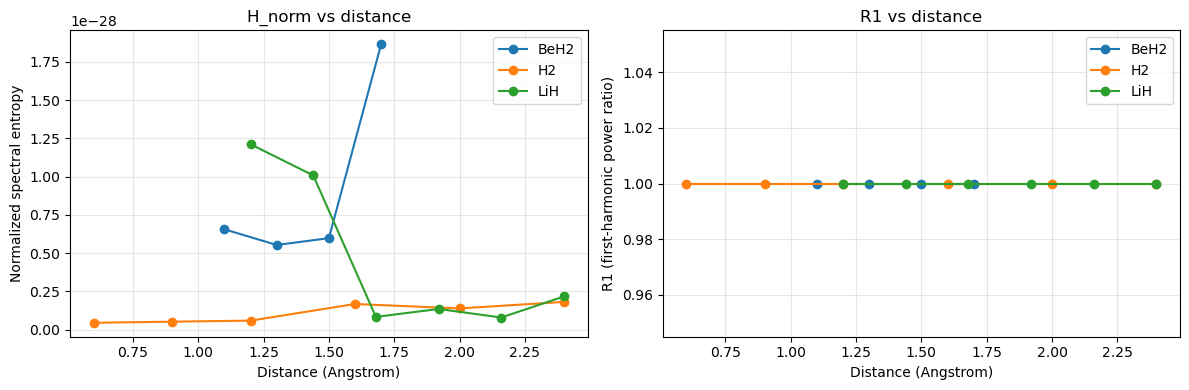

,system,median_r1,median_h_norm,median_rmse_k1,median_delta_emin_k1,mean_eval_count
0,BeH2,1.0,6.266139e-29,1.572566e-15,0.0,120.000000
1,H2,1.0,9.875388e-30,2.317719e-16,0.0,36.333333
2,LiH,1.0,1.759393e-29,6.067353e-16,0.0,120.000000


Quick interpretation:
BeH2: median R1=1.0000, median H_norm=0.0000, median RMSE@K1=1.573e-15, median DeltaEmin@K1=0.000e+00
H2: median R1=1.0000, median H_norm=0.0000, median RMSE@K1=2.318e-16, median DeltaEmin@K1=0.000e+00
LiH: median R1=1.0000, median H_norm=0.0000, median RMSE@K1=6.067e-16, median DeltaEmin@K1=0.000e+00


In [40]:
import matplotlib.pyplot as plt

if "conference_fast_df" not in globals() or "conference_summary_df" not in globals():
    raise RuntimeError("Run the previous cell first to generate conference_fast_df and conference_summary_df.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for system_name, sub in conference_fast_df.groupby("system"):
    sub = sub.sort_values("distance")
    ax[0].plot(sub["distance"], sub["h_norm"], marker="o", label=system_name)
    ax[1].plot(sub["distance"], sub["r1"], marker="o", label=system_name)

ax[0].set_xlabel("Distance (Angstrom)")
ax[0].set_ylabel("Normalized spectral entropy")
ax[0].set_title("H_norm vs distance")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].set_xlabel("Distance (Angstrom)")
ax[1].set_ylabel("R1 (first-harmonic power ratio)")
ax[1].set_title("R1 vs distance")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

display(conference_summary_df)

print("Quick interpretation:")
for _, row in conference_summary_df.iterrows():
    print(
        f"{row['system']}: median R1={row['median_r1']:.4f}, "
        f"median H_norm={row['median_h_norm']:.4f}, "
        f"median RMSE@K1={row['median_rmse_k1']:.3e}, "
        f"median DeltaEmin@K1={row['median_delta_emin_k1']:.3e}"
    )

## Global Multi-Direction Spectral Entropy Test
This section estimates spectral entropy on global random 1D cuts in parameter space.

- Use `global_system_toggle = "LiH"` or `"BeH2"`.
- Random centers + random directions increase harmonic mixing and can produce `H_norm > 0`.
- Keep `GLOBAL_FAST_MODE = True` for quick conference-style runs.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector
from scipy.fft import rfft

from src.vqe.hamiltonian import (
    build_electronic_hamiltonian,
    build_electronic_problem,
    build_qubit_hamiltonian,
    extract_problem_metadat,
 )
from src.vqe.ansatz import build_ansatz

# Toggle: "LiH" or "BeH2"
global_system_toggle = "BeH2"
GLOBAL_FAST_MODE = True
GLOBAL_SEED = 137

def _global_test_cfg(system_name: str):
    system = system_name.strip().lower()
    if system == "lih":
        cfg = {
            "label": "LiH",
            "basis": "sto-3g",
            "mapper": "jw",
            "z2": True,
            "freeze_core": True,
            "active_space": (2, 2),
            "active_orbitals": [0, 1],
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 2,
            "distances": np.array([1.2, 1.5, 1.8, 2.1, 2.4], dtype=float),
            "atom_fn": lambda d: f"Li 0 0 0; H 0 0 {d}",
        }
    elif system == "beh2":
        cfg = {
            "label": "BeH2",
            "basis": "sto-3g",
            "mapper": "jw",
            "z2": False,
            "freeze_core": True,
            "active_space": (4, 4),
            "active_orbitals": [0, 1, 2, 3],
            "ansatz_name": "real_amplitudes",
            "ansatz_reps": 2,
            "distances": np.array([1.1, 1.3, 1.5, 1.7], dtype=float),
            "atom_fn": lambda d: f"Be 0 0 0; H 0 0 {d}; H 0 0 {-d}",
        }
    else:
        raise ValueError("global_system_toggle must be 'LiH' or 'BeH2'.")

    if GLOBAL_FAST_MODE:
        cfg["n_centers"] = 3
        cfg["n_dirs"] = 3
        cfg["n_theta"] = 64
        cfg["t_span"] = 2.0 * np.pi
    else:
        cfg["n_centers"] = 8
        cfg["n_dirs"] = 8
        cfg["n_theta"] = 128
        cfg["t_span"] = 2.0 * np.pi

    return cfg

def _energy_line_statevector(ansatz, qubit_op, const_energy, center, direction, theta_grid):
    energies = []
    params = list(ansatz.parameters)
    for t in theta_grid:
        vec = center + t * direction
        bound = {p: float(v) for p, v in zip(params, vec)}
        sv = Statevector.from_instruction(ansatz.assign_parameters(bound))
        energies.append(float(np.real(sv.expectation_value(qubit_op)) + const_energy))
    return np.array(energies, dtype=float)

def _spectral_metrics(signal):
    centered = signal - np.mean(signal)
    fft_vals = rfft(centered)
    power = np.abs(fft_vals) ** 2
    power = power[1:]
    total = float(power.sum())

    if total <= 0.0:
        return {"r1": 1.0, "h_norm": 0.0}

    p = power / total
    eps = 1e-16
    h = float(-np.sum(p * np.log(p + eps)) / np.log(len(p))) if len(p) > 1 else 0.0
    r1 = float(p[0]) if len(p) > 0 else 1.0
    return {"r1": r1, "h_norm": h}

def _run_global_multidirection(system_name: str, seed: int = 137):
    cfg = _global_test_cfg(system_name)
    rng = np.random.default_rng(seed)
    rows = []

    print(f"Running global spectral test for {cfg['label']} (fast_mode={GLOBAL_FAST_MODE})")

    for d in cfg["distances"]:
        atom = cfg["atom_fn"](float(d))

        ferm_op, const_energy = build_electronic_hamiltonian(
            atom_string=atom,
            basis=cfg["basis"],
            active_space=cfg["active_space"],
            active_orbitals=cfg["active_orbitals"],
            freeze_core=cfg["freeze_core"],
        )
        problem = build_electronic_problem(
            atom_string=atom,
            basis=cfg["basis"],
            active_space=cfg["active_space"],
            active_orbitals=cfg["active_orbitals"],
            freeze_core=cfg["freeze_core"],
        )
        qubit_op = build_qubit_hamiltonian(
            ferm_op,
            mapper=cfg["mapper"],
            z2symmetry_reduction=cfg["z2"],
            problem=problem,
            num_particles=problem.num_particles,
        )

        meta = extract_problem_metadat(problem)
        ansatz = build_ansatz(
            name=cfg["ansatz_name"],
            num_qubits=qubit_op.num_qubits,
            reps=cfg["ansatz_reps"],
            num_particles=meta.get("num_particles"),
            num_spatial_orbitals=meta.get("num_spatial_orbitals"),
        )

        n_params = int(ansatz.num_parameters)
        theta_grid = np.linspace(-cfg["t_span"], cfg["t_span"], cfg["n_theta"], endpoint=False)

        for c_idx in range(cfg["n_centers"]):
            center = rng.uniform(-np.pi, np.pi, n_params)
            for u_idx in range(cfg["n_dirs"]):
                direction = rng.normal(size=n_params)
                direction = direction / (np.linalg.norm(direction) + 1e-12)

                e_line = _energy_line_statevector(
                    ansatz=ansatz,
                    qubit_op=qubit_op,
                    const_energy=const_energy,
                    center=center,
                    direction=direction,
                    theta_grid=theta_grid,
                )
                metrics = _spectral_metrics(e_line)

                rows.append({
                    "system": cfg["label"],
                    "distance": float(d),
                    "num_qubits": int(qubit_op.num_qubits),
                    "num_params": n_params,
                    "center_id": c_idx,
                    "direction_id": u_idx,
                    "r1": metrics["r1"],
                    "h_norm": metrics["h_norm"],
                })

    df = pd.DataFrame(rows)
    summary = (
        df.groupby(["system", "distance"], as_index=False)
        .agg(
            median_h_norm=("h_norm", "median"),
            p25_h_norm=("h_norm", lambda x: float(np.percentile(x, 25))),
            p75_h_norm=("h_norm", lambda x: float(np.percentile(x, 75))),
            median_r1=("r1", "median"),
            p25_r1=("r1", lambda x: float(np.percentile(x, 25))),
            p75_r1=("r1", lambda x: float(np.percentile(x, 75))),
        )
    )

    return df, summary, cfg

global_multi_df, global_multi_summary_df, global_multi_cfg = _run_global_multidirection(
    system_name=global_system_toggle,
    seed=GLOBAL_SEED,
 )

display(global_multi_summary_df)
print("\nOverall median H_norm:", float(global_multi_df["h_norm"].median()))
print("Overall median R1:", float(global_multi_df["r1"].median()))
print("Any H_norm > 0.01?", bool((global_multi_df["h_norm"] > 0.01).any()))

Running global spectral test for BeH2 (fast_mode=True)


,system,distance,median_h_norm,p25_h_norm,p75_h_norm,median_r1,p25_r1,p75_r1
0,BeH2,1.1,0.225956,0.150828,0.371141,0.637775,0.512313,0.814380
1,BeH2,1.3,0.154326,0.126639,0.176370,0.857190,0.813090,0.887104
2,BeH2,1.5,0.251063,0.210088,0.268697,0.715511,0.605038,0.774492
3,BeH2,1.7,0.208104,0.122286,0.255540,0.707035,0.608432,0.860645



Overall median H_norm: 0.2090958366481275
Overall median R1: 0.7757085855272094
Any H_norm > 0.01? True


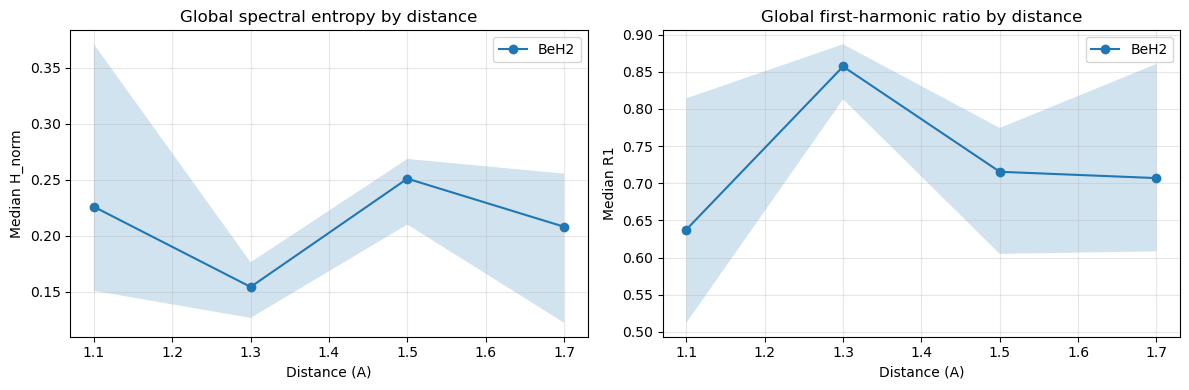

,system,distance,num_qubits,num_params,center_id,direction_id,r1,h_norm
0,BeH2,1.1,8,24,0,0,0.512313,0.371141
1,BeH2,1.1,8,24,0,1,0.566489,0.390890
2,BeH2,1.1,8,24,0,2,0.448734,0.533599
3,BeH2,1.1,8,24,1,0,0.776925,0.225956
4,BeH2,1.1,8,24,1,1,0.929620,0.104802
5,BeH2,1.1,8,24,1,2,0.921042,0.105455
6,BeH2,1.1,8,24,2,0,0.637775,0.369218
7,BeH2,1.1,8,24,2,1,0.153992,0.150828
8,BeH2,1.1,8,24,2,2,0.814380,0.187529
9,BeH2,1.3,8,24,0,0,0.887104,0.126639


In [21]:
if "global_multi_df" not in globals() or "global_multi_summary_df" not in globals():
    raise RuntimeError("Run the global test cell first.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for system_name, sub in global_multi_summary_df.groupby("system"):
    sub = sub.sort_values("distance")
    ax[0].plot(sub["distance"], sub["median_h_norm"], marker="o", label=system_name)
    ax[0].fill_between(sub["distance"], sub["p25_h_norm"], sub["p75_h_norm"], alpha=0.2)

    ax[1].plot(sub["distance"], sub["median_r1"], marker="o", label=system_name)
    ax[1].fill_between(sub["distance"], sub["p25_r1"], sub["p75_r1"], alpha=0.2)

ax[0].set_xlabel("Distance (A)")
ax[0].set_ylabel("Median H_norm")
ax[0].set_title("Global spectral entropy by distance")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].set_xlabel("Distance (A)")
ax[1].set_ylabel("Median R1")
ax[1].set_title("Global first-harmonic ratio by distance")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

display(global_multi_df.head(10))